# Gaussian Process Regression (GPR) Foreground Removal

This notebook implements GPR foreground removal for HI intensity mapping data simulated with the `meer21cm` package.

### Structure
1. [Imports & Setup](#1-imports--setup)
2. [Simulation Setup](#2-simulation-setup)
3. [Covariance Analysis](#3-covariance-analysis)
4. [Kernel Exploration](#4-kernel-exploration)
5. [GPR Functions](#6-gpr-functions)
6. [Kernel Parameter Optimisation](#7-kernel-parameter-optimisation)
7. [MCMC — Model 1: RBF without Spectral Index](#8-mcmc--model-1-rbf-without-spectral-index)
8. [MCMC — Model 2: RBF with Spectral Index](#9-mcmc--model-2-rbf-with-spectral-index)
9. [Matérn Kernel Comparison](#10-matern-kernel-comparison)
10. [Model Comparison (Log Marginal Likelihood)](#11-model-comparison-log-marginal-likelihood)
11. [GPR Power Spectrum with MCMC Uncertainty](#12-gpr-power-spectrum-with-mcmc-uncertainty)


## 1. Imports & Setup

In [56]:
import numpy as np
import matplotlib.pyplot as plt
import os
import time
import glob

# meer21cm simulation tools
from meer21cm import MockSimulation
from meer21cm.plot import plot_map
from meer21cm.fg import ForegroundSimulation
from meer21cm.util import pca_clean

# GPR kernel functions (defined in gpr.py)
from gpr import *

# Optimisation
from scipy import optimize
from scipy.special import gamma, kv

# MCMC
import emcee
import corner

# Parallel processing
from joblib import Parallel, delayed
from tqdm import tqdm

from matplotlib import ticker

In [57]:
# ── Global plot settings ──────────────────────────────────────────────────
plt.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 16,
    'axes.titlesize': 18,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
})

# ── Helper: save plots to project output folder ───────────────────────────
def save_project_plot(fig, week_number, filename):
    """Save a matplotlib figure to outputs/weekN/filename."""
    base_path = "/Users/gracetait/shproject/senior_honours_project/outputs"
    target_dir = os.path.join(base_path, f"week{week_number}")
    os.makedirs(target_dir, exist_ok=True)
    filepath = os.path.join(target_dir, filename)
    fig.savefig(filepath, bbox_inches='tight')
    print(f"Successfully saved: {filepath}")

# ── Number of CPU cores for parallelisation ───────────────────────────────
num_processes = os.cpu_count()
print(f"Available CPU cores: {num_processes}")

Available CPU cores: 8


## 2. Simulation Setup

Generate the mock HI signal, foreground, and thermal noise maps using `meer21cm`.

- **HI signal**: mock 21cm intensity map with seed=42 for reproducibility
- **Foreground**: Haslam-based synchrotron foreground with spectral index γ = -2.7 (injected truth)
- **Noise**: Gaussian white noise with σ = 1.21 × 10⁻³ K (from MeerKLASS 2024)

In [58]:
# ── Generate HI mock simulation ───────────────────────────────────────────
mock = MockSimulation(
    survey='meerklass_2021',
    band='L',
    flat_sky=True,
    seed=42,
    omega_hi=5e-4,
    mean_amp_1='average_hi_temp',
    tracer_bias_1=1.0,
)

# ── Generate foreground simulation ────────────────────────────────────────
# Injected spectral index: sp_indx_for_haslam_backend = -2.7 (this is the truth we try to recover)
fgsim = ForegroundSimulation(
    hp_nside=128,
    wproj=mock.wproj,
    num_pix_x=mock.num_pix_x,
    num_pix_y=mock.num_pix_y,
    backend='haslam',
    sp_indx_for_haslam_backend=-2.7,
)

# ── Extract maps ──────────────────────────────────────────────────────────
hi_map = mock.propagate_mock_field_to_data(mock.mock_tracer_field_1)
fg_map = fgsim.fg_wcs_cube(mock.nu)

# ── Generate thermal noise ────────────────────────────────────────────────
# Gaussian white noise scaled by survey weights — purely diagonal covariance
sigma_noise = 1.21e-3  # K (from MeerKLASS 2024, Table 1)
noise_map = np.random.default_rng(mock.seed).normal(0, sigma_noise, hi_map.shape) * mock.w_HI

# ── Total observed map ────────────────────────────────────────────────────
tot_map = hi_map + fg_map + noise_map

print(f"Frequency range: {mock.nu[0]/1e6:.1f} – {mock.nu[-1]/1e6:.1f} MHz")
print(f"Number of frequency channels: {len(mock.nu)}")
print(f"Map shape (ra, dec, freq): {hi_map.shape}")
print(f"HI amplitude (rms):        {hi_map.std():.2e} K")
print(f"Foreground amplitude (rms): {fg_map.std():.2e} K")
print(f"Noise amplitude (rms):      {noise_map.std():.2e} K")
print(f"Foreground/HI ratio:        {fg_map.std()/hi_map.std():.0f}x")

Frequency range: 971.2 – 1023.6 MHz
Number of frequency channels: 252
Map shape (ra, dec, freq): (133, 73, 252)
HI amplitude (rms):        1.90e-04 K
Foreground amplitude (rms): 1.86e-01 K
Noise amplitude (rms):      1.18e-03 K
Foreground/HI ratio:        980x


## 3. Covariance Analysis

Extract frequency-frequency covariance matrices for each component. The covariance structure motivates our choice of GPR kernels:
- **Foreground**: smooth, slowly varying → RBF (squared exponential) kernel
- **HI signal**: rapidly varying, short correlation length → exponential kernel  
- **Noise**: purely diagonal (white noise) → diagonal kernel

In [59]:
# ── Extract covariance matrices from each component ──────────────────────
# pca_clean with return_analysis=True returns (covariance, eigenvalues, eigenvectors, ...)
# N_fg=0 means no modes are removed — we just want the covariance
cov_hi,    _, _, _ = pca_clean(hi_map,    0, weights=mock.w_HI, return_analysis=True, mean_center=True)
cov_fg,    _, _, _ = pca_clean(fg_map,    0, weights=mock.w_HI, return_analysis=True, mean_center=True)
cov_noise, _, _, _ = pca_clean(noise_map, 0, weights=mock.w_HI, return_analysis=True, mean_center=True)
cov_tot,   _, _, _ = pca_clean(tot_map,   0, weights=mock.w_HI, return_analysis=True, mean_center=True)

print(f"cov_tot shape:              {cov_tot.shape}")
print(f"cov_tot diagonal mean:      {np.diag(cov_tot).mean():.4f}")
print(f"cov_tot off-diagonal mean:  {cov_tot[0,1]:.4f}")
print(f"cov_fg diagonal mean:       {np.diag(cov_fg).mean():.4f}")
print(f"cov_hi diagonal mean:       {np.diag(cov_hi).mean():.6f}")
print(f"cov_noise diagonal mean:    {np.diag(cov_noise).mean():.6f}")

cov_tot shape:              (252, 252)
cov_tot diagonal mean:      0.0280
cov_tot off-diagonal mean:  0.0322
cov_fg diagonal mean:       0.0280
cov_hi diagonal mean:       0.000000
cov_noise diagonal mean:    0.000001


Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week9/tot_fg_hi_noise_covariance.pdf


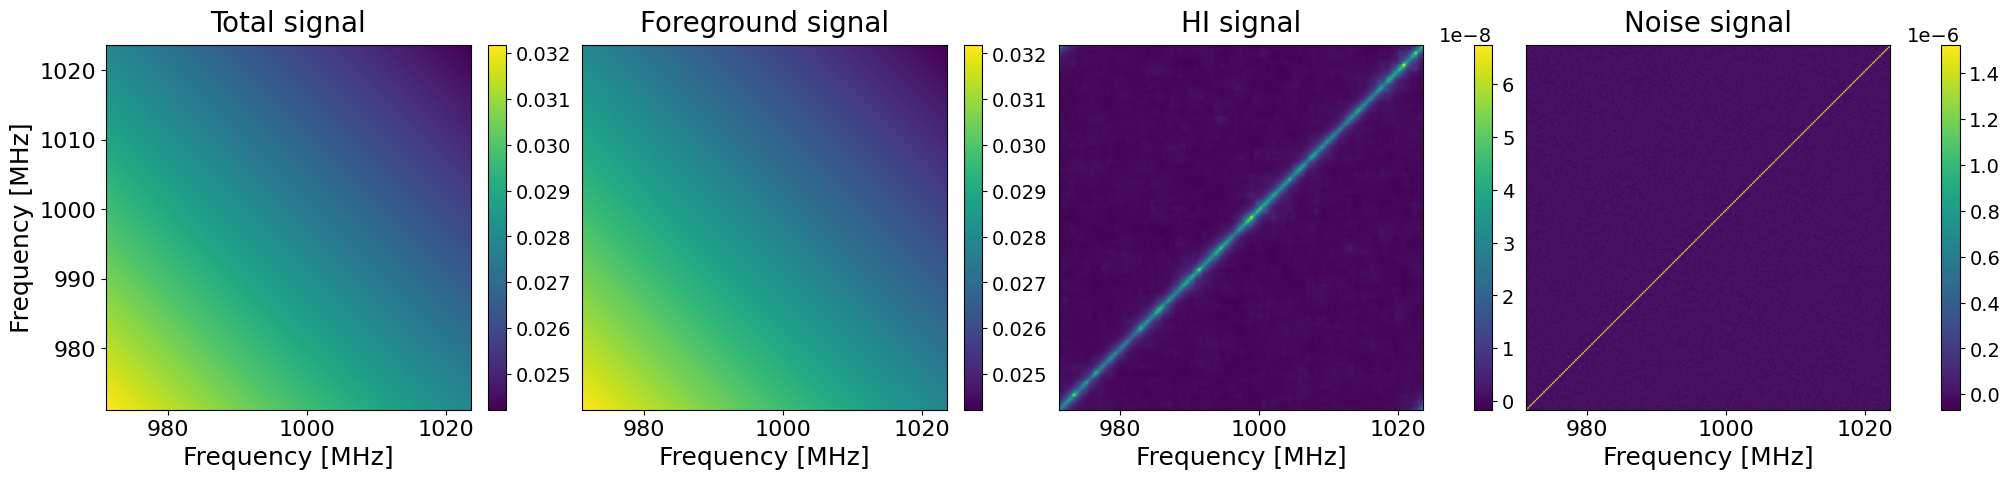

In [22]:
# plot the covariance of the HI, foreground, and noise signals
fig, axes = plt.subplots(1, 4, figsize=(20, 6), layout="constrained") # Reduced height to 6 for better aspect ratio

# Define shared parameters
extent = [mock.nu[0]/1e6, mock.nu[-1]/1e6, mock.nu[0]/1e6, mock.nu[-1]/1e6]
titles = ['Total signal', 'Foreground signal', 'HI signal', 'Noise signal']
covs = [cov_tot, cov_fg, cov_hi, cov_noise]

fs = 18

for i, (ax, cov, title) in enumerate(zip(axes, covs, titles)):
    im = ax.imshow(cov, origin='lower', extent=extent)
    
    # Add colorbar to each individual axis
    plt.colorbar(im, ax=ax, location='right', fraction=0.05, pad=0.04)
    
    # X-axis is the same for all
    ax.set_xlabel('Frequency [MHz]', fontsize=fs)
    ax.set_title(title, fontsize=fs+2, pad = 10)
    ax.tick_params(axis='x', labelsize=fs-2)

    # Y-axis logic: Only keep for the first plot
    if i == 0:
        ax.set_ylabel('Frequency [MHz]', fontsize=fs)
        ax.tick_params(axis='y', labelsize=fs-2)
    else:
        # This removes both the tick marks and the numbers
        ax.set_yticklabels([]) 
        ax.set_yticks([])

save_project_plot(plt.gcf(), week_number=9, filename="tot_fg_hi_noise_covariance.pdf")
plt.show()

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week9/tot_fg_hi_covariance.pdf


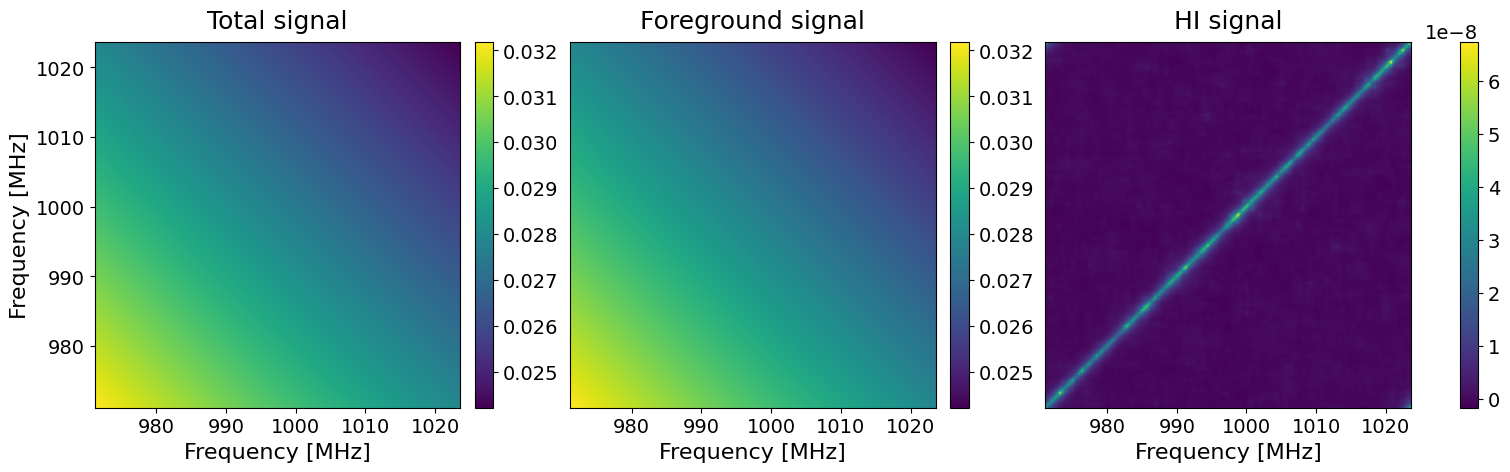

In [78]:
# plot the covariance of the HI, foreground, and noise signals
fig, axes = plt.subplots(1, 3, figsize=(15, 8), layout="constrained") # Reduced height to 6 for better aspect ratio

# Define shared parameters
extent = [mock.nu[0]/1e6, mock.nu[-1]/1e6, mock.nu[0]/1e6, mock.nu[-1]/1e6]
titles = ['Total signal', 'Foreground signal', 'HI signal']
covs = [cov_tot, cov_fg, cov_hi]

fs = 16

for i, (ax, cov, title) in enumerate(zip(axes, covs, titles)):
    im = ax.imshow(cov, origin='lower', extent=extent)
    
    # Add colorbar to each individual axis
    cb = fig.colorbar(im, ax=ax, location='right', fraction=0.05, pad=0.04)
    cb.ax.tick_params(labelsize=fs-2)
    cb.ax.yaxis.get_offset_text().set_fontsize(fs-2)
    
    # X-axis is the same for all
    ax.set_xlabel('Frequency [MHz]', fontsize=fs)
    ax.set_title(title, fontsize=fs+2, pad = 10)
    ax.tick_params(axis='x', labelsize=fs-2)

    # Y-axis logic: Only keep for the first plot
    if i == 0:
        ax.set_ylabel('Frequency [MHz]', fontsize=fs)
        ax.tick_params(axis='y', labelsize=fs-2)
    else:
        # This removes both the tick marks and the numbers
        ax.set_yticklabels([]) 
        ax.set_yticks([])

save_project_plot(plt.gcf(), week_number=9, filename="tot_fg_hi_covariance.pdf")
plt.show()

## 4. Kernel Exploration

Explore how the exponential and RBF kernels behave for different parameter values.
This motivates the choice of kernel for each component.

In [24]:
# ── Initial parameter estimates from covariance matrices ──────────────────
sigma_hi_kern = np.sqrt(np.diagonal(cov_hi).mean())
sigma_fg_kern = np.sqrt(np.diagonal(cov_fg).mean())
l_hi          = 1.0    # MHz — short correlation length for HI
l_fg          = 400.0  # MHz — long correlation length for foreground
sp_indx_fg    = -2.7   # spectral index starting guess (= injected truth)

print("Initial kernel parameter estimates:")
print(f"  sigma_hi_kern: {sigma_hi_kern:.6f}")
print(f"  sigma_fg_kern: {sigma_fg_kern:.6f}")
print(f"  l_hi:          {l_hi} MHz")
print(f"  l_fg:          {l_fg} MHz")
print(f"  sp_indx_fg:    {sp_indx_fg}")

Initial kernel parameter estimates:
  sigma_hi_kern: 0.000190
  sigma_fg_kern: 0.167264
  l_hi:          1.0 MHz
  l_fg:          400.0 MHz
  sp_indx_fg:    -2.7


Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week6/exp_kernel_lengthscales_2.pdf


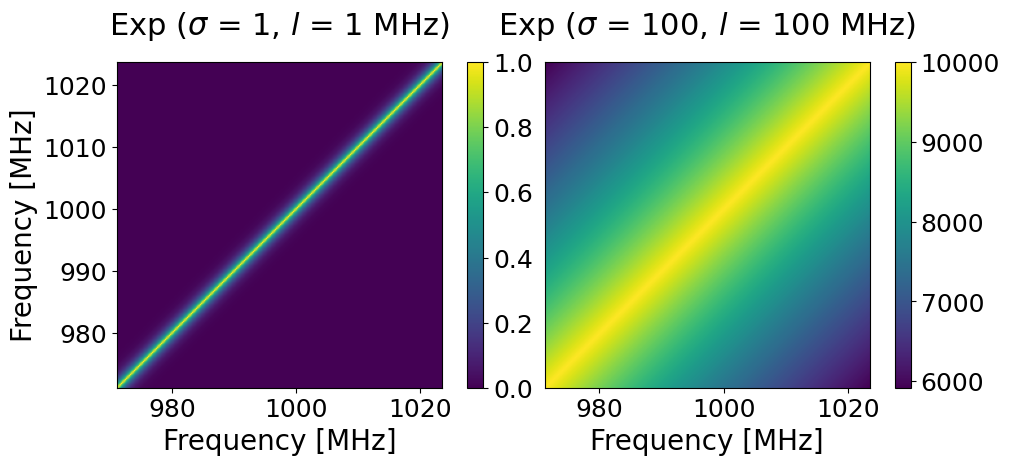

In [25]:
# plot the exponential kernals

fs = 20

exp_kern_3 = exponential_kernel(mock.nu/1e6,mock.nu/1e6,1,1)
exp_kern_4 = exponential_kernel(mock.nu/1e6,mock.nu/1e6,100,100)

fig,axes = plt.subplots(1,2,figsize=(10,5), layout = "constrained")
im = axes[0].imshow(exp_kern_3,origin='lower',extent=[mock.nu[0]/1e6,mock.nu[-1]/1e6,mock.nu[0]/1e6,mock.nu[-1]/1e6])
cb1 = fig.colorbar(im, location='right', fraction = 0.05)
cb1.ax.tick_params(labelsize=fs-2)
axes[0].set_xlabel('Frequency [MHz]', fontsize=fs)
axes[0].set_ylabel('Frequency [MHz]', fontsize=fs)
axes[0].set_title(r'Exp ($\sigma$ = 1, $l$ = 1 MHz)', fontsize=fs+2, pad = 20)
axes[0].tick_params(labelsize=fs-2)

im = axes[1].imshow(exp_kern_4,origin='lower',extent=[mock.nu[0]/1e6,mock.nu[-1]/1e6,mock.nu[0]/1e6,mock.nu[-1]/1e6])
cb2 = fig.colorbar(im, location='right', fraction = 0.05)
cb2.ax.tick_params(labelsize=fs-2)
axes[1].set_xlabel('Frequency [MHz]', fontsize=fs)
#axes[1].set_ylabel('Frequency [MHz]', fontsize=fs)
axes[1].set_title(r'Exp ($\sigma$ = 100, $l$ = 100 MHz)', fontsize=fs+2, pad = 20)
axes[1].tick_params(labelsize=fs-2)
axes[1].set_yticklabels([]) 
axes[1].set_yticks([])

save_project_plot(plt.gcf(), week_number = 6, filename = "exp_kernel_lengthscales_2.pdf")
plt.show()

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week6/rbf_kernels_lengthscales_2.pdf


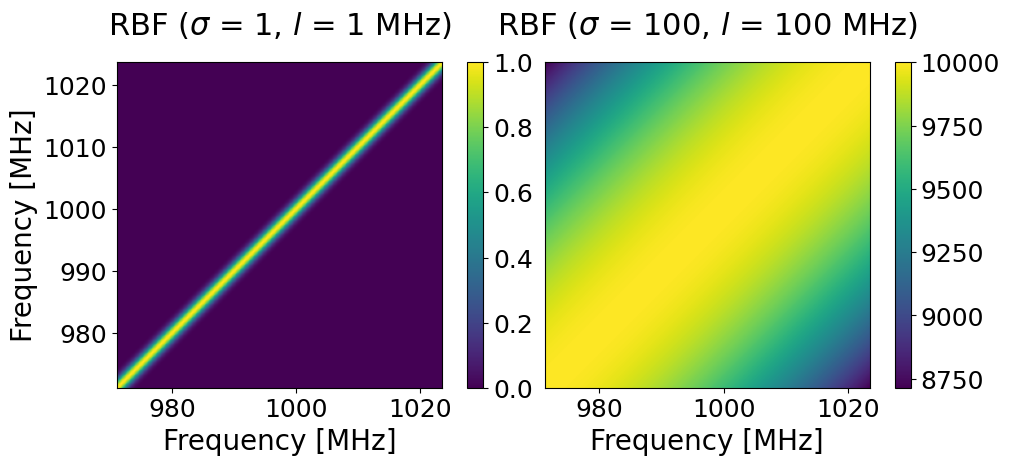

In [26]:
# plot the rbf kernals

rbf_kern_3 = rbf_kernel(mock.nu/1e6,mock.nu/1e6,1,1)
rbf_kern_4 = rbf_kernel(mock.nu/1e6,mock.nu/1e6,100,100)

fig,axes = plt.subplots(1,2,figsize=(10,5), layout = "constrained")
im = axes[0].imshow(rbf_kern_3,origin='lower',extent=[mock.nu[0]/1e6,mock.nu[-1]/1e6,mock.nu[0]/1e6,mock.nu[-1]/1e6])
cb1 = fig.colorbar(im, location='right', fraction = 0.05)
cb1.ax.tick_params(labelsize=fs-2)
axes[0].set_xlabel('Frequency [MHz]', fontsize=fs)
axes[0].set_ylabel('Frequency [MHz]', fontsize=fs)
axes[0].set_title(r'RBF ($\sigma$ = 1, $l$ = 1 MHz)', fontsize=fs+2, pad = 20)
axes[0].tick_params(labelsize=fs-2)

im = axes[1].imshow(rbf_kern_4,origin='lower',extent=[mock.nu[0]/1e6,mock.nu[-1]/1e6,mock.nu[0]/1e6,mock.nu[-1]/1e6])
cb2 = fig.colorbar(im, location='right', fraction = 0.05)
cb2.ax.tick_params(labelsize=fs-2)
axes[1].set_xlabel('Frequency [MHz]', fontsize=fs)
#axes[1].set_ylabel('Frequency [MHz]', fontsize=fs)
axes[1].set_title(r'RBF ($\sigma$ = 100, $l$ = 100 MHz)', fontsize=fs+2, pad = 20)
axes[1].tick_params(labelsize=fs-2)
axes[1].set_yticklabels([]) 
axes[1].set_yticks([])

save_project_plot(plt.gcf(), week_number = 6, filename = "rbf_kernels_lengthscales_2.pdf")
plt.show()

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week6/rbf_kernel_w_sp_indx_vs_foreground_covariance.pdf


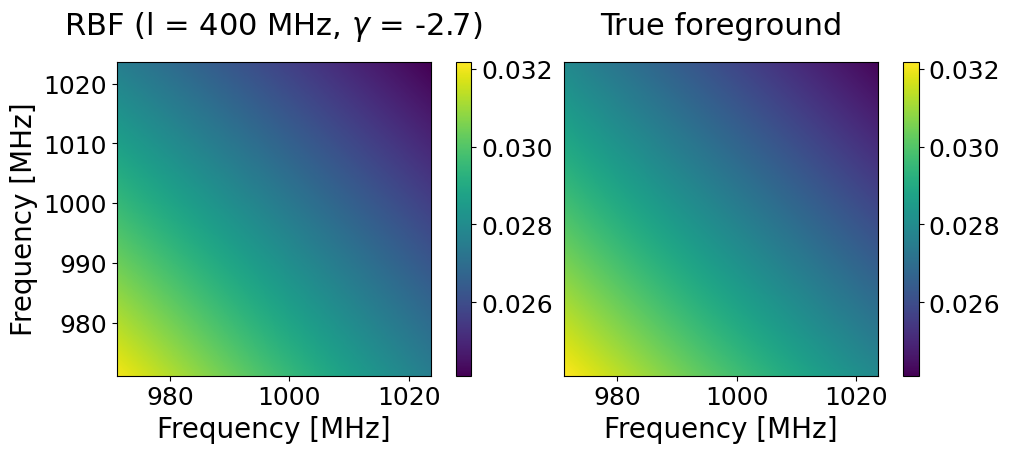

In [27]:
sigma_fg_kern = np.sqrt(np.diagonal(cov_fg).mean())* 1.07
l_fg = 400
sp_indx_fg = -2.7
rbf_kern_fg = rbf_kernel(mock.nu/1e6,mock.nu/1e6,sigma_fg_kern,l_fg,sp_indx_fg)
vmin = np.min([rbf_kern_fg.min(), cov_fg.min()])
vmax = np.max([rbf_kern_fg.max(), cov_fg.max()])
fig,axes = plt.subplots(1,2,figsize=(10,5), layout = "constrained")
im = axes[0].imshow(rbf_kern_fg,origin='lower',extent=[mock.nu[0]/1e6,mock.nu[-1]/1e6,mock.nu[0]/1e6,mock.nu[-1]/1e6],vmin=vmin,vmax=vmax)
cb1 = fig.colorbar(im, location='right', fraction = 0.05)
cb1.ax.tick_params(labelsize=fs-2)
axes[0].set_xlabel('Frequency [MHz]', fontsize=fs)
axes[0].set_ylabel('Frequency [MHz]', fontsize=fs)
axes[0].set_title(f'RBF (l = {l_fg} MHz, $\gamma$ = {sp_indx_fg})', fontsize=fs+2, pad = 20)
axes[0].tick_params(labelsize=fs-2)

im = axes[1].imshow(cov_fg,origin='lower',extent=[mock.nu[0]/1e6,mock.nu[-1]/1e6,mock.nu[0]/1e6,mock.nu[-1]/1e6],vmin=vmin,vmax=vmax)
cb2 = fig.colorbar(im, location='right', fraction = 0.05)
cb2.ax.tick_params(labelsize=fs-2)
axes[1].set_xlabel('Frequency [MHz]', fontsize=fs)
#axes[1].set_ylabel('Frequency [MHz]', fontsize=fs)
axes[1].set_title('True foreground', fontsize=fs+2, pad = 20)
axes[1].tick_params(labelsize=fs-2)
axes[1].set_yticklabels([]) 
axes[1].set_yticks([])

save_project_plot(plt.gcf(), week_number = 6, filename = "rbf_kernel_w_sp_indx_vs_foreground_covariance.pdf")
plt.show()

## 5. GPR Functions

In [155]:
# ── Foreground removal and power spectrum utility ─────────────────────────

def gpr_foreground_removal(fitted_pars, sp_indx_fg=True):
    
    k_hi = exponential_kernel(mock.nu/1e6, mock.nu/1e6, fitted_pars[0], fitted_pars[2])
    
    if sp_indx_fg:
        k_fg = rbf_kernel(mock.nu/1e6, mock.nu/1e6, fitted_pars[1], fitted_pars[3], fitted_pars[4])
    else:
        k_fg = rbf_kernel_no_sp_indx(mock.nu/1e6, mock.nu/1e6, fitted_pars[1], fitted_pars[3])
    
    k_tot_fitted = k_fg + k_hi
    wiener       = k_fg @ np.linalg.inv(k_tot_fitted)
    
    # Cleaned map: subtract GP estimate of foreground
    fg_remov  = np.einsum('ij, abj->abi', wiener, tot_map)
    res_map   = tot_map - fg_remov
    
    # Noise residual: used to subtract noise power from power spectrum
    noise_residual = np.einsum('ij, abj->abi', np.eye(mock.nu.size) - wiener, noise_map)
    return res_map, noise_residual


def compute_power_spectra(res_map, noise_residual, noise = True):
    
    mock.kparabins = np.linspace(0.01, 1, 11)
    mock.kperpbins = np.linspace(0.01, 0.5, 21)
    mock.k1dbins   = np.linspace(0, 1.2, 21)

    mock.data = hi_map
    mock.grid_data_to_field()
    power_cy_hi, _ = mock.get_cy_power(mock.auto_power_3d_1)
    power_1d_hi, k_1d, _ = mock.get_1d_power(mock.auto_power_3d_1)

    mock.data = res_map
    mock.grid_data_to_field()
    power_cy_res, _ = mock.get_cy_power(mock.auto_power_3d_1)
    power_1d_res, _, _ = mock.get_1d_power(mock.auto_power_3d_1)

    if noise == True:

        mock.data = noise_residual
        mock.grid_data_to_field()
        power_cy_noise, _ = mock.get_cy_power(mock.auto_power_3d_1)
        power_1d_noise, _, _ = mock.get_1d_power(mock.auto_power_3d_1)
    
        power_cy_res -= power_cy_noise
        power_1d_res -= power_1d_noise

    return power_1d_hi, power_1d_res, power_cy_hi, power_cy_res, k_1d


def plot_gpr_power_spectra(fitted_pars, sp_indx_fg=True, method='gpr', save_plot=False, week_number=None, noise=True):

    fs = 16
    
    res_map, noise_residual = gpr_foreground_removal(fitted_pars, sp_indx_fg)
    power_1d_hi, power_1d_res, power_cy_hi, power_cy_res, k_1d = compute_power_spectra(res_map, noise_residual, noise)

    # 1D log power spectrum
    fig, ax = plt.subplots(figsize=(8, 5), layout = "constrained")
    ax.plot(k_1d, np.log10(power_1d_hi),  label='HI signal', color='blue', linewidth=1.5)
    ax.plot(k_1d, np.log10(power_1d_res), label='Residual signal',     color='red',  linewidth=1.5, ls='--')
    ax.set_xlabel('k [Mpc$^{-1}$]', fontsize=fs)
    ax.set_ylabel(r'log$_{10}$ P(k) [Mpc$^3$K$^2$]', fontsize=fs)
    ax.set_title(f'1D Power Spectrum', fontsize=fs+2)
    ax.legend(fontsize=fs)
    if save_plot:
        save_project_plot(fig, week_number=week_number, filename=f'gpr_1d_power_{method}.pdf')
    plt.show()

    # Cylindrical power spectrum
    vmin = np.log10([power_cy_hi.min(), power_cy_res.min()]).min()
    vmax = np.log10([power_cy_hi.max(), power_cy_res.max()]).max()
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5), layout='constrained')
    axes[0].pcolormesh(mock.kperpbins, mock.kparabins, np.log10(power_cy_hi.T),  vmin=vmin, vmax=vmax)
    axes[0].set_title('HI signal', fontsize=fs+2)
    axes[0].set_ylabel('k$_\parallel$ [Mpc$^{-1}$]', fontsize = fs)
    
    im = axes[1].pcolormesh(mock.kperpbins, mock.kparabins, np.log10(power_cy_res.T), vmin=vmin, vmax=vmax)
    axes[1].set_title('Residual signal', fontsize=fs+2)
    axes[1].set_yticklabels([]) 
    axes[1].set_yticks([])
    cbar = plt.colorbar(im, ax=axes[:2], location='top', aspect=50, pad=0.04)
    cbar.set_label(r'log$_{10}$ P(k$_\perp$, k$_\parallel$) [Mpc$^3$K$^2$]', labelpad = 10)
    cbar.ax.tick_params(labelsize=fs-2)
    cbar.ax.yaxis.get_offset_text().set_fontsize(fs-2)
    
    im2 = axes[2].pcolormesh(mock.kperpbins, mock.kparabins, power_cy_res.T/power_cy_hi.T, cmap='bwr')
    axes[2].set_title('Ratio', fontsize=fs+2)
    axes[2].set_yticklabels([]) 
    axes[2].set_yticks([])
    cbar = plt.colorbar(im2, ax=axes[2], location='top', aspect=23, pad=0.04)
    cbar.ax.tick_params(labelsize=fs-2)
    cbar.ax.yaxis.get_offset_text().set_fontsize(fs-2)
    
    for ax in axes:
        ax.set_xlabel('k$_\perp$ [Mpc$^{-1}$]')
    if save_plot:
        save_project_plot(fig, week_number=week_number, filename=f'gpr_cylindrical_{method}.pdf')
    plt.show()

In [166]:
# ── Kernel comparison plots ───────────────────────────────────────────────

def plot_kernel_comparison(fitted_pars, sp_indx_fg=True, method='gpr',
                            save_plot=False, week_number=None, noise = True):

    fs = 20

    extent = [mock.nu[0]/1e6, mock.nu[-1]/1e6, mock.nu[0]/1e6, mock.nu[-1]/1e6]

    k_hi = exponential_kernel(mock.nu/1e6, mock.nu/1e6, fitted_pars[0], fitted_pars[2])
    
    if sp_indx_fg:
        k_fg = rbf_kernel(mock.nu/1e6, mock.nu/1e6, fitted_pars[1], fitted_pars[3], fitted_pars[4])
    else:
        k_fg = rbf_kernel_no_sp_indx(mock.nu/1e6, mock.nu/1e6, fitted_pars[1], fitted_pars[3])

    fig, axes = plt.subplots(1, 4, figsize=(20, 5), layout='constrained')

    if noise == True:
    
        # HI kernel vs noise covariance
        vmin = min(k_hi.min(), cov_noise.min())
        vmax = max(k_hi.max(), cov_noise.max())
        im = axes[0].imshow(k_hi,      origin='lower', extent=extent) #, vmin=vmin, vmax=vmax)
        cbar = fig.colorbar(im, ax=axes[0], location='right', fraction=0.046, pad=0.04)
        cbar.ax.tick_params(labelsize=fs-2)
        cbar.ax.yaxis.get_offset_text().set_fontsize(fs-2)
        axes[0].set_title('Fitted HI + noise kernel', fontsize=fs+2, pad = 10)
        axes[0].set_xlabel('Frequency [MHz]', fontsize=fs)
        axes[0].set_ylabel('Frequency [MHz]', fontsize=fs)
        axes[0].tick_params(labelsize=fs-2)
    
        im = axes[1].imshow(cov_noise, origin='lower') #, extent=extent, vmin=vmin, vmax=vmax)
        cbar = fig.colorbar(im, ax=axes[1], location='right', fraction=0.046, pad=0.04)
        cbar.ax.tick_params(labelsize=fs-2)
        cbar.ax.yaxis.get_offset_text().set_fontsize(fs-2)
        axes[1].set_title('Noise covariance', fontsize=fs+2, pad = 10)
        axes[1].set_xlabel('Frequency [MHz]', fontsize=fs)
        axes[1].tick_params(labelsize=fs-2)
        axes[1].set_yticklabels([]) 
        axes[1].set_yticks([])

    else:

        # HI kernel vs (no) noise covariance
        vmin = min(k_hi.min(), cov_hi.min())
        vmax = max(k_hi.max(), cov_hi.max())
        im = axes[0].imshow(k_hi,      origin='lower') #, extent=extent, vmin=vmin, vmax=vmax)
        cbar = fig.colorbar(im, ax=axes[0], location='right', fraction=0.046, pad=0.04)
        cbar.ax.tick_params(labelsize=fs-2)
        cbar.ax.yaxis.get_offset_text().set_fontsize(fs-2)
        axes[0].set_title('HI kernel', fontsize=fs+2, pad = 10)
        axes[0].set_xlabel('Frequency [MHz]', fontsize=fs)
        axes[0].set_ylabel('Frequency [MHz]', fontsize=fs)
        axes[0].tick_params(labelsize=fs-2)
    
        im = axes[1].imshow(cov_hi, origin='lower') #, extent=extent, vmin=vmin, vmax=vmax)
        cbar = fig.colorbar(im, ax=axes[1], location='right', fraction=0.046, pad=0.04)
        cbar.ax.tick_params(labelsize=fs-2)
        cbar.ax.yaxis.get_offset_text().set_fontsize(fs-2)
        axes[1].set_title('True HI', fontsize=fs+2, pad = 10)
        axes[1].set_xlabel('Frequency [MHz]', fontsize=fs)
        axes[1].tick_params(labelsize=fs-2)
        axes[1].set_yticklabels([]) 
        axes[1].set_yticks([])

    # Foreground kernel vs foreground covariance
    #vmin = min(k_fg.min(), cov_fg.min())
    #vmax = max(k_fg.max(), cov_fg.max())
    im = axes[2].imshow(k_fg,    origin='lower', extent=extent) #, vmin=vmin, vmax=vmax)
    cbar = fig.colorbar(im, ax=axes[2], location='right', fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=fs-2)
    cbar.ax.yaxis.get_offset_text().set_fontsize(fs-2)
    axes[2].set_title('Foreground kernel', fontsize=fs+2, pad = 10)
    axes[2].set_xlabel('Frequency [MHz]', fontsize=fs)
    axes[2].tick_params(labelsize=fs-2)
    axes[2].set_yticklabels([]) 
    axes[2].set_yticks([])

    im = axes[3].imshow(cov_fg,  origin='lower', extent=extent) #, vmin=vmin, vmax=vmax)
    cbar = fig.colorbar(im, ax=axes[3], location='right', fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=fs-2)
    cbar.ax.yaxis.get_offset_text().set_fontsize(fs-2)
    axes[3].set_title('True foreground', fontsize=fs+2, pad = 10)
    axes[3].set_xlabel('Frequency [MHz]', fontsize=fs)
    axes[3].tick_params(labelsize=fs-2)
    axes[3].set_yticklabels([]) 
    axes[3].set_yticks([])

    if save_plot:
        save_project_plot(fig, week_number=week_number,
                          filename=f'kernel_comparison_{method}.pdf')
    plt.show()

## 6. Kernel Parameter Optimisation

### 6.1 Total signal with noise, RBF kernel with spectral index
Using scipy optimize minimize

In [131]:
tot_map = hi_map + fg_map + noise_map
#tot_map = hi_map + fg_map
cov_tot, __, __, __ = pca_clean(tot_map, 1, weights = mock.w_HI, return_analysis = True, mean_center = True)

In [132]:
# lets try a different scipy optimise function = minimize
x0 = np.array([sigma_hi_kern, sigma_fg_kern * 1.02, l_hi, l_fg, sp_indx_fg], dtype = float)
#x0 = np.array([sigma_hi_kern, sigma_fg_kern * 1.02, l_hi, l_fg], dtype = float)
args = (mock.nu / 1e6, cov_tot)
bounds = bounds = [
    (1e-6, 0.5),   # Amplitudes must be positive
    (1e-6, 0.5), 
    (0.01, 2.0),  # hi length scale (MHz)
    (10.0, 1000.0),  # foreground length scale (MHz)
    (-5, -0.1)    # spectral index can be anything
]
best_fit = optimize.minimize(fun = function_to_optimise, x0 = x0, args = args, bounds = bounds, method = 'Nelder-Mead',
    options={'maxiter': 2000, 'maxfev': 5000})

In [133]:
print(f"Optimization Success: {best_fit.success}")
print(f"Reason for stopping: {best_fit.message}")
print(f"Optimized Parameters: {best_fit.x}")
print(f"Log-Marginial Likeligood: {best_fit.fun}")
lml_1 = best_fit.fun
fitted_pars = best_fit.x

Optimization Success: True
Reason for stopping: Optimization terminated successfully.
Optimized Parameters: [ 1.29240549e-03  1.27862972e-01  1.00000000e-02  9.99999999e+02
 -2.72572866e+00]
Log-Marginial Likeligood: -1539.7033506545201


In [134]:
print(x0)
print(fitted_pars)

[ 1.90448375e-04  1.82551820e-01  1.00000000e+00  4.00000000e+02
 -2.70000000e+00]
[ 1.29240549e-03  1.27862972e-01  1.00000000e-02  9.99999999e+02
 -2.72572866e+00]


Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week9/kernel_comparison_scipy_with_noise_and_sp_indx.pdf


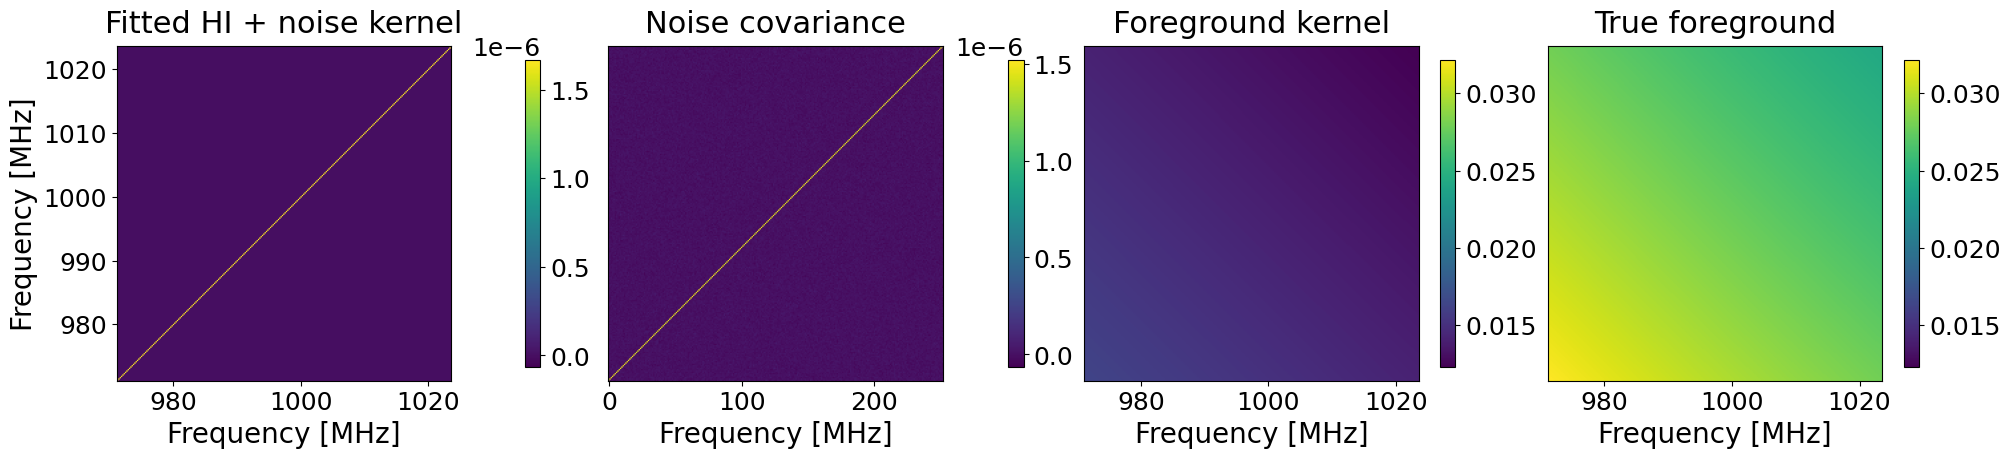

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week9/gpr_1d_power_scipy_with_noise_and_sp_indx.pdf


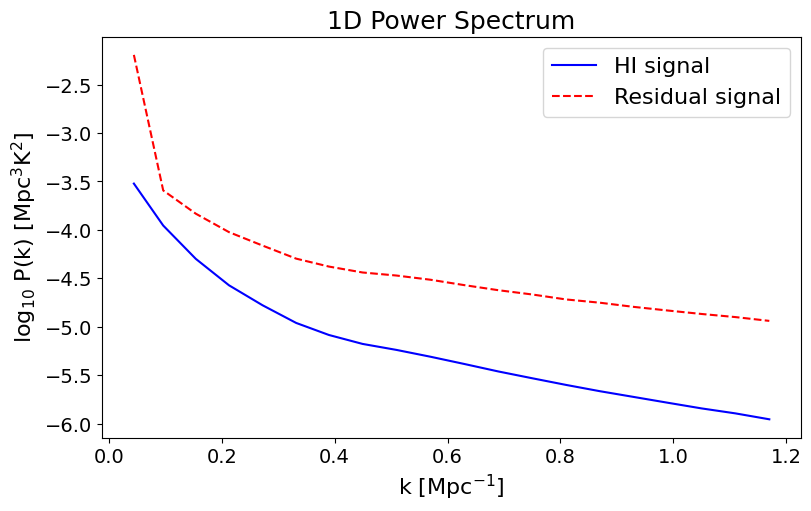

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week9/gpr_cylindrical_scipy_with_noise_and_sp_indx.pdf


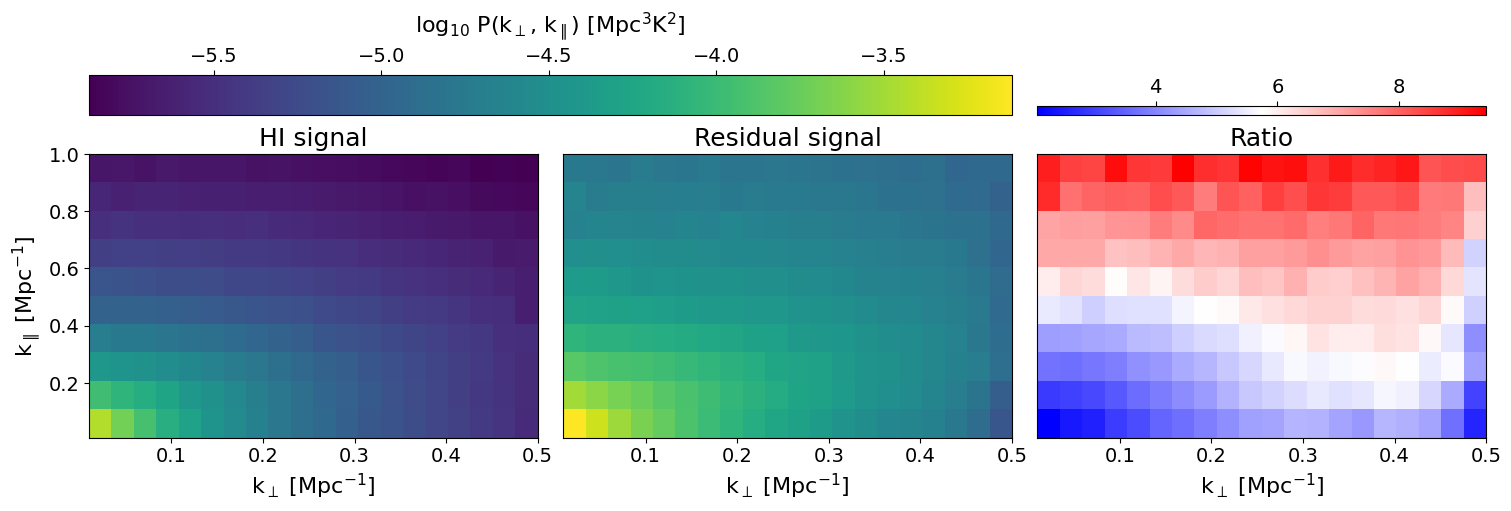

In [135]:
# ── Kernel comparison: with spectral index ────────────────────────────────
plot_kernel_comparison(fitted_pars, sp_indx_fg=True, method='scipy_with_noise_and_sp_indx',
                       save_plot=True, week_number=9, noise = True)

# ── Power spectrum: with spectral index ───────────────────────────────────
plot_gpr_power_spectra(fitted_pars, sp_indx_fg=True, method='scipy_with_noise_and_sp_indx',
                       save_plot=True, week_number=9, noise=True)

### 6.2 Total signal with noise, RBF kernel without spectral index
Using scipy optimize minimize

In [136]:
tot_map = hi_map + fg_map + noise_map
#tot_map = hi_map + fg_map
cov_tot, __, __, __ = pca_clean(tot_map, 1, weights = mock.w_HI, return_analysis = True, mean_center = True)

In [137]:
# lets try a different scipy optimise function = minimize
#x0 = np.array([sigma_hi_kern, sigma_fg_kern * 1.02, l_hi, l_fg, sp_indx_fg], dtype = float)
x0 = np.array([sigma_hi_kern, sigma_fg_kern * 1.02, l_hi, l_fg], dtype = float)
args = (mock.nu / 1e6, cov_tot)
bounds = bounds = [
    (1e-6, 0.5),   # Amplitudes must be positive
    (1e-6, 0.5), 
    (0.01, 2.0),  # hi length scale (MHz)
    (10.0, 1000.0)  # foreground length scale (MHz)
    #(-5, -0.1)    # spectral index can be anything
]
best_fit = optimize.minimize(fun = function_to_optimise_no_sp_indx, x0 = x0, args = args, bounds = bounds, method = 'Nelder-Mead',
    options={'maxiter': 2000, 'maxfev': 5000})

In [138]:
print(f"Optimization Success: {best_fit.success}")
print(f"Reason for stopping: {best_fit.message}")
print(f"Optimized Parameters: {best_fit.x}")
print(f"Log-Marginial Likeligood: {best_fit.fun}")
lml_2 = best_fit.fun
fitted_pars = best_fit.x

Optimization Success: True
Reason for stopping: Optimization terminated successfully.
Optimized Parameters: [1.29148926e-03 2.28213446e-01 1.00000000e-02 4.11594968e+02]
Log-Marginial Likeligood: -1536.752867002602


In [139]:
print(x0)
print(fitted_pars)

[1.90448375e-04 1.82551820e-01 1.00000000e+00 4.00000000e+02]
[1.29148926e-03 2.28213446e-01 1.00000000e-02 4.11594968e+02]


Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week9/kernel_comparison_scipy_with_noise_and_no_sp_indx.pdf


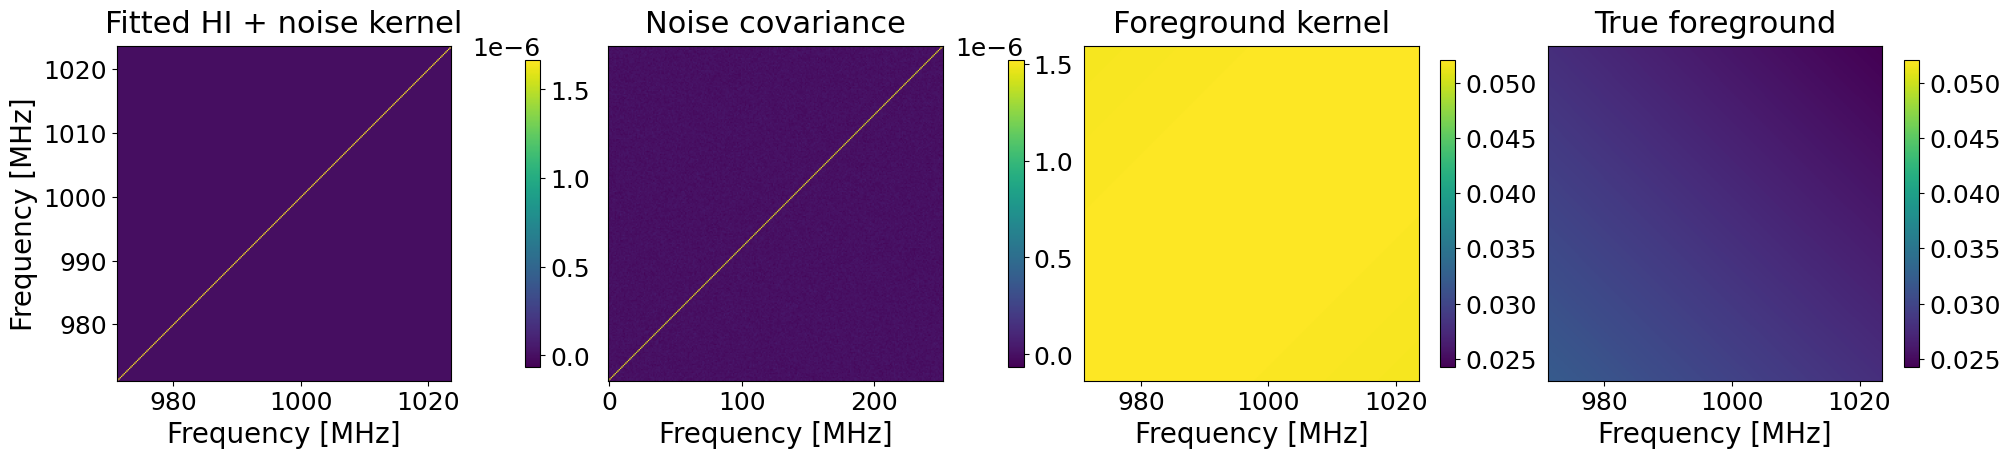

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week9/gpr_1d_power_scipy_with_noise_and_no_sp_indx.pdf


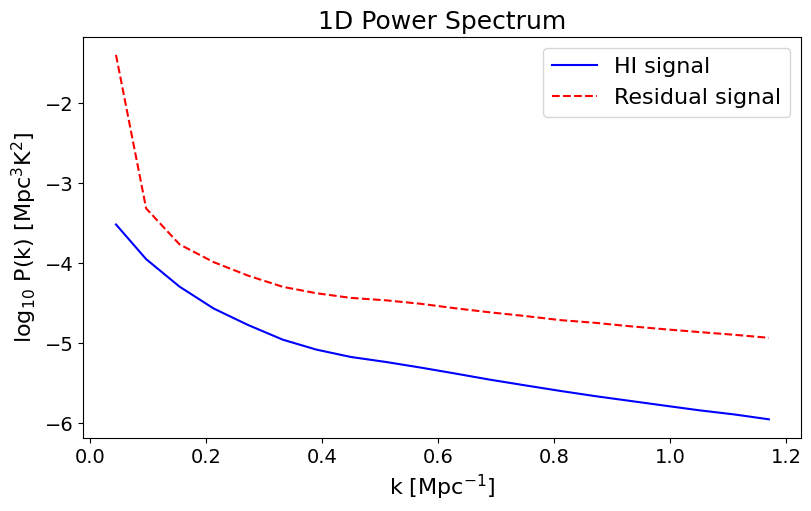

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week9/gpr_cylindrical_scipy_with_noise_and_no_sp_indx.pdf


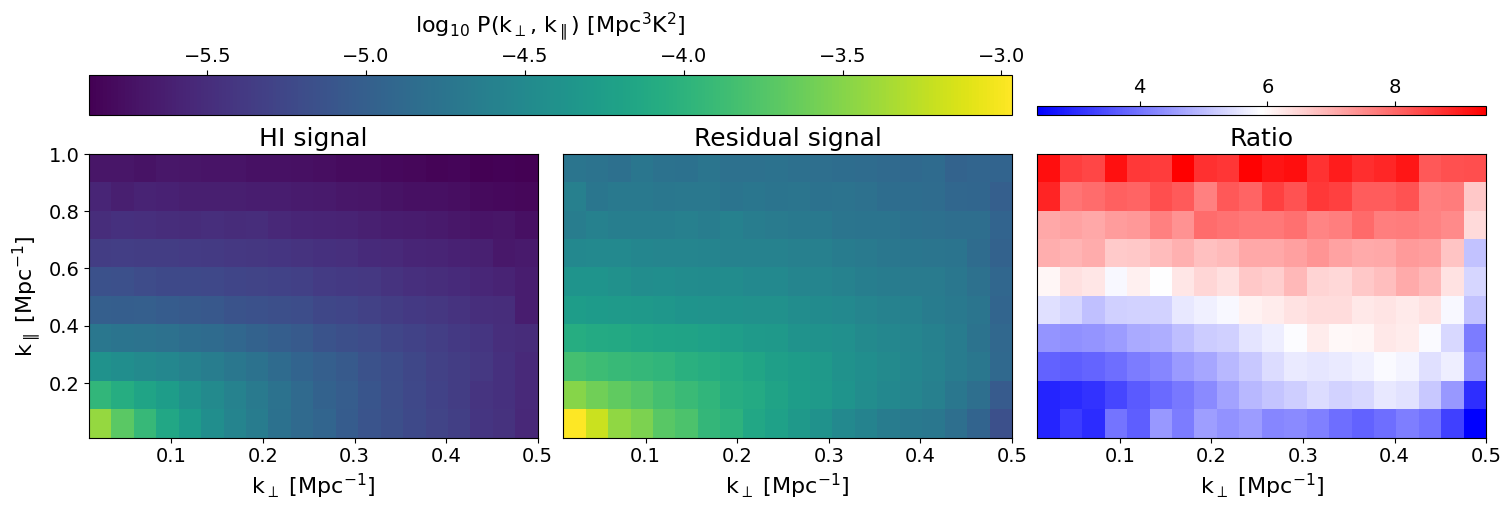

In [140]:
# ── Kernel comparison: with spectral index ────────────────────────────────
plot_kernel_comparison(fitted_pars, sp_indx_fg=False, method='scipy_with_noise_and_no_sp_indx',
                       save_plot=True, week_number=9, noise = True)

# ── Power spectrum: with spectral index ───────────────────────────────────
plot_gpr_power_spectra(fitted_pars, sp_indx_fg=False, method='scipy_with_noise_and_no_sp_indx',
                       save_plot=True, week_number=9, noise=True)

### 6.3 Total signal without noise, RBF kernel with spectral index
Using scipy optimize minimize

In [141]:
#tot_map = hi_map + fg_map + noise_map
tot_map = hi_map + fg_map
cov_tot, __, __, __ = pca_clean(tot_map, 1, weights = mock.w_HI, return_analysis = True, mean_center = True)

In [142]:
# lets try a different scipy optimise function = minimize
x0 = np.array([sigma_hi_kern, sigma_fg_kern * 1.02, l_hi, l_fg, sp_indx_fg], dtype = float)
#x0 = np.array([sigma_hi_kern, sigma_fg_kern * 1.02, l_hi, l_fg], dtype = float)
args = (mock.nu / 1e6, cov_tot)
bounds = bounds = [
    (1e-6, 0.5),   # Amplitudes must be positive
    (1e-6, 0.5), 
    (0.01, 2.0),  # hi length scale (MHz)
    (10.0, 1000.0),  # foreground length scale (MHz)
    (-5, -0.1)    # spectral index can be anything
]
best_fit = optimize.minimize(fun = function_to_optimise, x0 = x0, args = args, bounds = bounds, method = 'Nelder-Mead',
    options={'maxiter': 2000, 'maxfev': 5000})

In [143]:
print(f"Optimization Success: {best_fit.success}")
print(f"Reason for stopping: {best_fit.message}")
print(f"Optimized Parameters: {best_fit.x}")
print(f"Log-Marginial Likeligood: {best_fit.fun}")
lml_3 = best_fit.fun
fitted_pars = best_fit.x

Optimization Success: True
Reason for stopping: Optimization terminated successfully.
Optimized Parameters: [ 1.94282378e-04  1.27857439e-01  1.21221612e+00  1.00000000e+03
 -2.77588568e+00]
Log-Marginial Likeligood: -2170.3872961074026


In [144]:
print(x0)
print(fitted_pars)

[ 1.90448375e-04  1.82551820e-01  1.00000000e+00  4.00000000e+02
 -2.70000000e+00]
[ 1.94282378e-04  1.27857439e-01  1.21221612e+00  1.00000000e+03
 -2.77588568e+00]


Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week9/kernel_comparison_scipy_with_no_noise_and_sp_indx.pdf


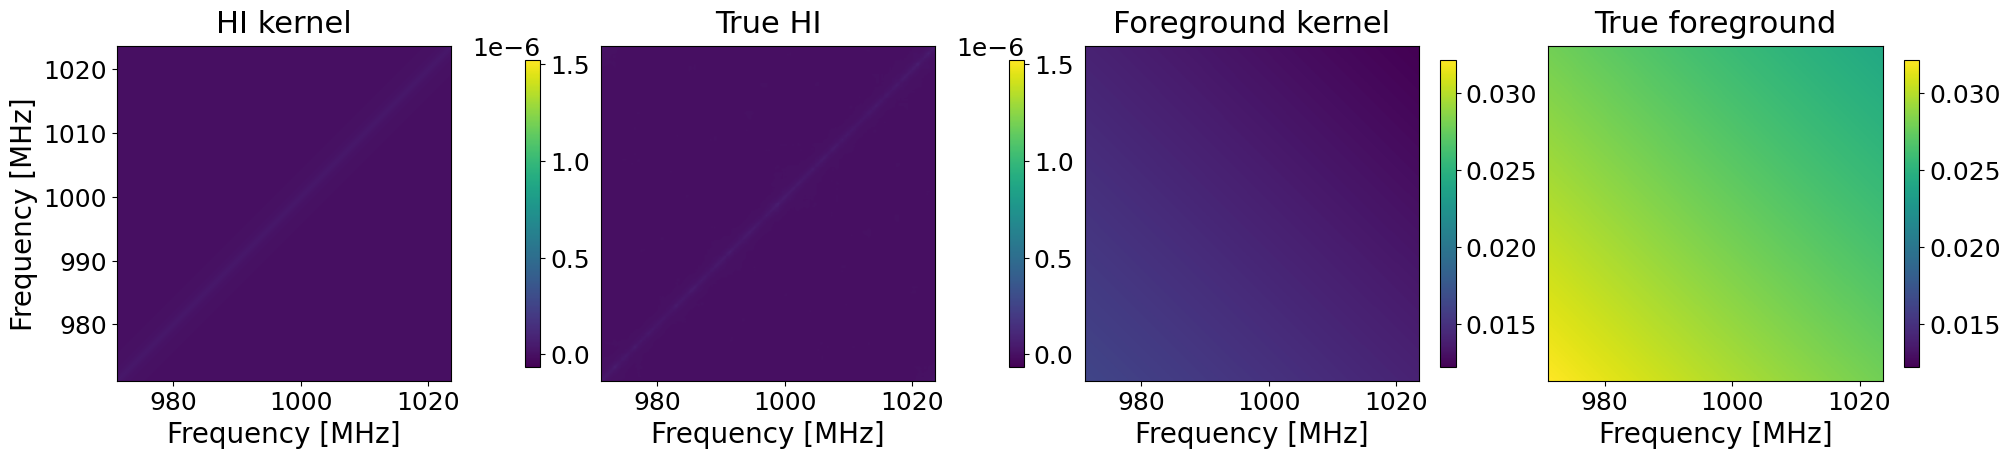

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week9/gpr_1d_power_scipy_with_no_noise_and_sp_indx.pdf


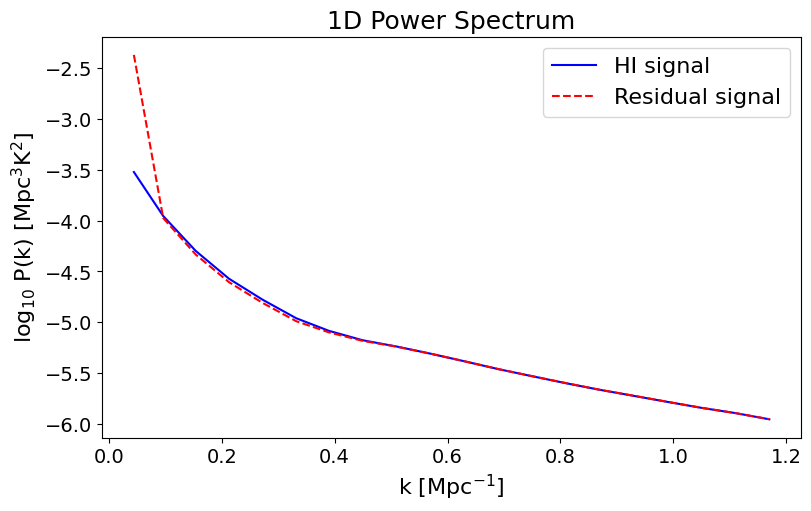

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week9/gpr_cylindrical_scipy_with_no_noise_and_sp_indx.pdf


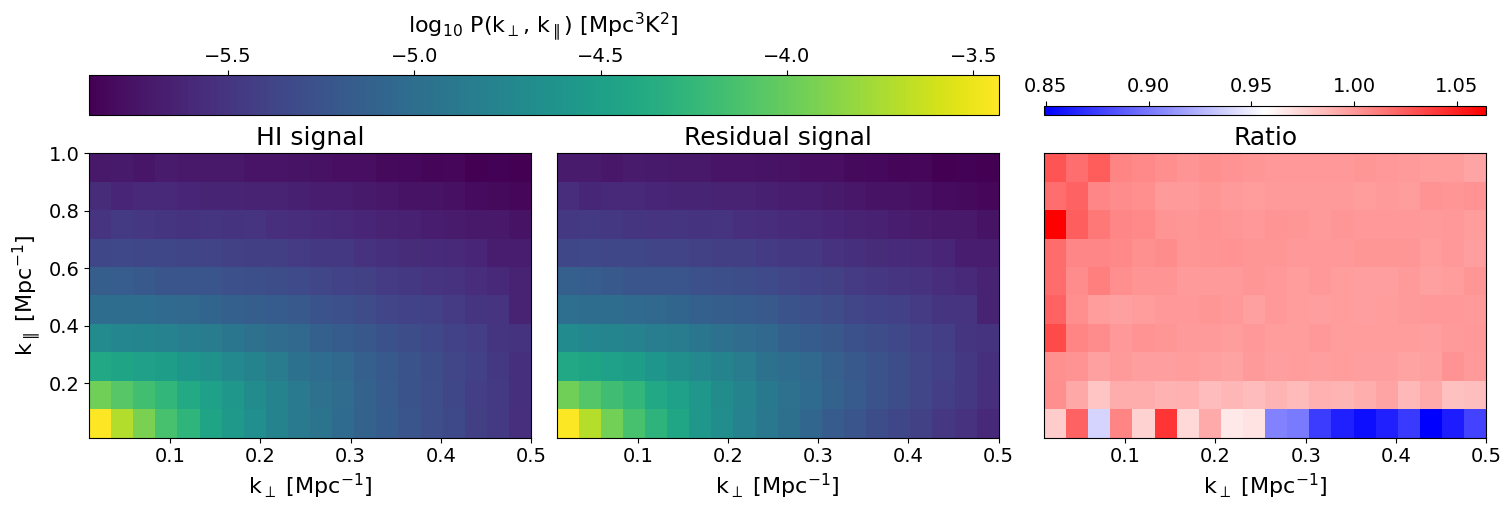

In [145]:
# ── Kernel comparison: with spectral index ────────────────────────────────
plot_kernel_comparison(fitted_pars, sp_indx_fg=True, method='scipy_with_no_noise_and_sp_indx',
                       save_plot=True, week_number=9, noise = False)

# ── Power spectrum: with spectral index ───────────────────────────────────
plot_gpr_power_spectra(fitted_pars, sp_indx_fg=True, method='scipy_with_no_noise_and_sp_indx',
                       save_plot=True, week_number=9, noise=False)

### 6.4 Total signal without noise, RBF kernel without spectral index
Using scipy optimize minimize

In [146]:
#tot_map = hi_map + fg_map + noise_map
tot_map = hi_map + fg_map
cov_tot, __, __, __ = pca_clean(tot_map, 1, weights = mock.w_HI, return_analysis = True, mean_center = True)

In [147]:
# lets try a different scipy optimise function = minimize
#x0 = np.array([sigma_hi_kern, sigma_fg_kern * 1.02, l_hi, l_fg, sp_indx_fg], dtype = float)
x0 = np.array([sigma_hi_kern, sigma_fg_kern * 1.02, l_hi, l_fg], dtype = float)
args = (mock.nu / 1e6, cov_tot)
bounds = bounds = [
    (1e-6, 0.5),   # Amplitudes must be positive
    (1e-6, 0.5), 
    (0.01, 2.0),  # hi length scale (MHz)
    (10.0, 1000.0)  # foreground length scale (MHz)
    #(-5, -0.1)    # spectral index can be anything
]
best_fit = optimize.minimize(fun = function_to_optimise_no_sp_indx, x0 = x0, args = args, bounds = bounds, method = 'Nelder-Mead',
    options={'maxiter': 2000, 'maxfev': 5000})

In [148]:
print(f"Optimization Success: {best_fit.success}")
print(f"Reason for stopping: {best_fit.message}")
print(f"Optimized Parameters: {best_fit.x}")
print(f"Log-Marginial Likeligood: {best_fit.fun}")
lml_4 = best_fit.fun
fitted_pars = best_fit.x

Optimization Success: True
Reason for stopping: Optimization terminated successfully.
Optimized Parameters: [1.95147601e-04 2.38282025e-01 1.22475836e+00 4.21793146e+02]
Log-Marginial Likeligood: -2166.5513419027407


In [149]:
print(x0)
print(fitted_pars)

[1.90448375e-04 1.82551820e-01 1.00000000e+00 4.00000000e+02]
[1.95147601e-04 2.38282025e-01 1.22475836e+00 4.21793146e+02]


Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week9/kernel_comparison_scipy_with_no_noise_and_no_sp_indx.pdf


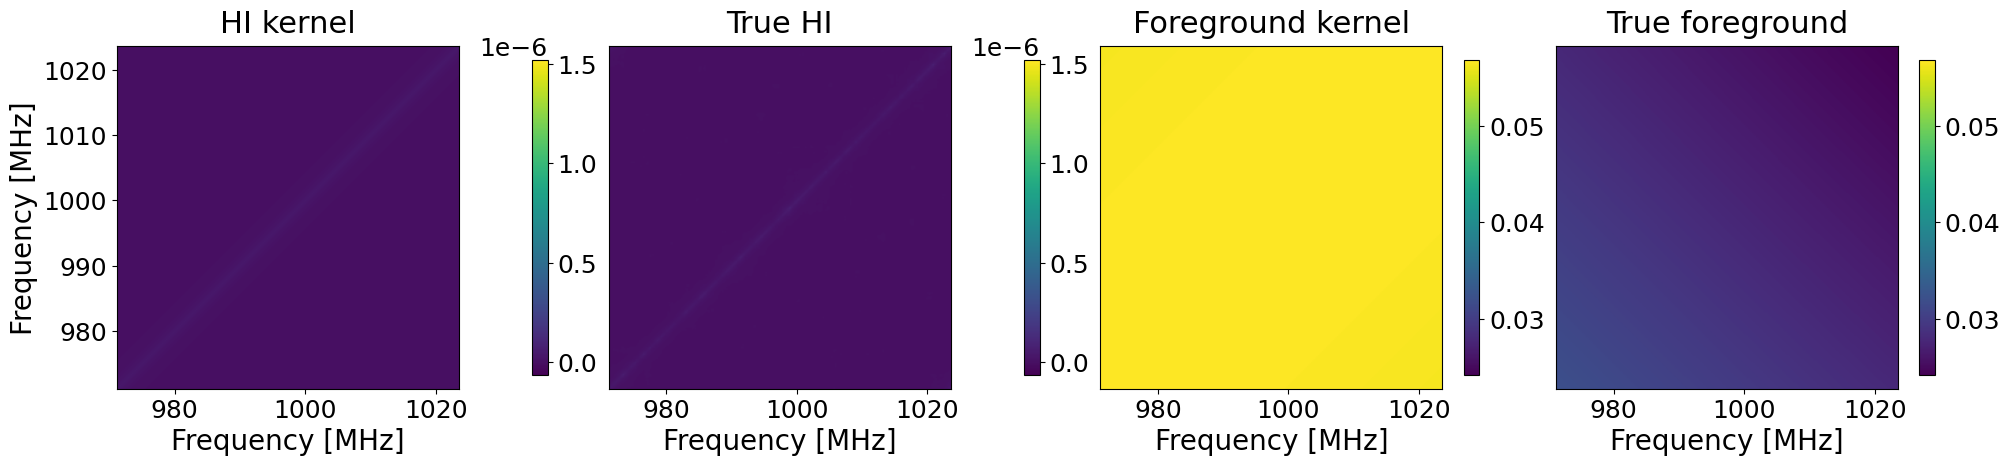

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week9/gpr_1d_power_scipy_with_no_noise_and_no_sp_indx.pdf


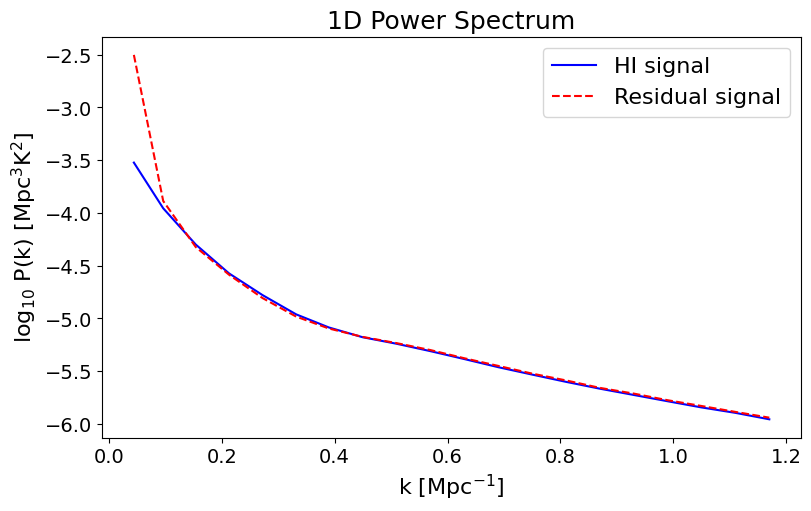

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week9/gpr_cylindrical_scipy_with_no_noise_and_no_sp_indx.pdf


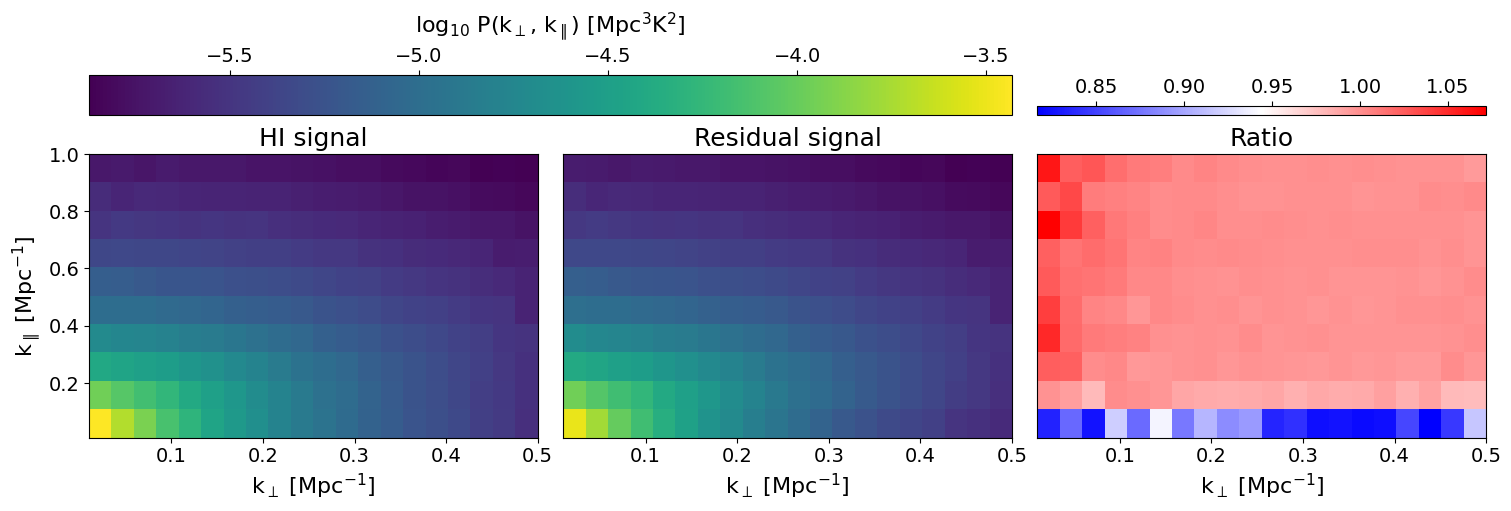

In [150]:
# ── Kernel comparison: with spectral index ────────────────────────────────
plot_kernel_comparison(fitted_pars, sp_indx_fg=False, method='scipy_with_no_noise_and_no_sp_indx',
                       save_plot=True, week_number=9, noise = False)

# ── Power spectrum: with spectral index ───────────────────────────────────
plot_gpr_power_spectra(fitted_pars, sp_indx_fg=False, method='scipy_with_no_noise_and_no_sp_indx',
                       save_plot=True, week_number=9, noise=False)

## 7. Model Comparison (Log Marginial Likelihood)

Compare the three models using the LML from scipy optimize minimize
The Jeffreys scale for Bayes factors (difference in LML):
- ΔLML < 1: no evidence
- 1–3: weak/marginal evidence
- 3–5: **moderate evidence** ← expected result
- 5: strong evidence

In [115]:
# ── LML comparison between models ─────────────────────────────────────────
print("=" * 60)
print("MODEL COMPARISON — Log Marginal Likelihood")
print("=" * 60)
print(f"  Model 1 (RBF, spectral index, with noise):  LML = {lml_1:.2f}")
print(f"  Model 2 (RBF, no noise spectral index, with noise):    LML = {lml_2:.2f}")
print(f"  Model 3 (RBF, spectral index, without noise):  LML = {lml_3:.2f}")
print(f"  Model 4 (RBF, no noise spectral index, without noise):    LML = {lml_4:.2f}")
print()
print(f"  Δ(Model 2 vs Model 1) = {lml_2 - lml_1:.2f}")
print(f"  Δ(Model 3 vs Model 1) = {lml_3  - lml_1:.2f}")
print(f"  Δ(Model 4 vs Model 1) = {lml_4  - lml_1:.2f}")
print(lml_4 - lml_3)

MODEL COMPARISON — Log Marginal Likelihood
  Model 1 (RBF, spectral index, with noise):  LML = -1539.70
  Model 2 (RBF, no noise spectral index, with noise):    LML = -1536.75
  Model 3 (RBF, spectral index, without noise):  LML = -2170.39
  Model 4 (RBF, no noise spectral index, without noise):    LML = -2166.55

  Δ(Model 2 vs Model 1) = 2.95
  Δ(Model 3 vs Model 1) = -630.68
  Δ(Model 4 vs Model 1) = -626.85
3.8359542046619026


## 8. MCMC Sampling - Total signal without noise, with spectral index

### Initial run

In [202]:
# ── Log prior and posterior ─────────────────

def log_prior(params):
    """Flat (uniform) prior within physically motivated bounds."""
    sigma_hi, sigma_fg, l_hi, l_fg, sp_indx_fg = params
    if (1e-6  < sigma_hi   < 0.5   and
        1e-6  < sigma_fg   < 0.5   and
        0.01  < l_hi       < 2.0   and
        10.0  < l_fg       < 1000.0 and
        -5.0  < sp_indx_fg < -1.0):
        return 0.0
    return -np.inf

def log_posterior(params, xarr, cov_tot):
    lp = log_prior(params)
    if not np.isfinite(lp):
        return -np.inf
    ll = function_to_optimise(
        params, xarr=xarr, cov_tot=cov_tot, minimise=False
    )
    return lp + ll if np.isfinite(ll) else -np.inf

In [207]:
tot_map = hi_map + fg_map #+ noise_map
cov_tot, __, __, __ = pca_clean(tot_map, 0, weights = mock.w_HI, return_analysis = True, mean_center = True)

In [208]:
# initialise walkers near the best guess x0
x0 = np.array([sigma_hi_kern, sigma_fg_kern * 1.02, l_hi, l_fg, sp_indx_fg], dtype=float)
#x0 = fitted_pars # from differential evolution

ndim     = len(x0)   # now 5
nwalkers = 100        # 100 walkers
nburn    = 1000
nsteps   = 10000
discard = 1000 # discard burn in 

rng = np.random.default_rng(42)
p0  = x0[None, :] + 1e-3 * rng.standard_normal((nwalkers, ndim)) * x0[None, :]

# Prior check — ensure all walkers start inside prior
for i in range(nwalkers):
    while not np.isfinite(log_prior(p0[i])):
        p0[i] = x0 + 1e-3 * rng.standard_normal(ndim) * x0

In [209]:
# initialise walkers near the best guess x0
x0 = np.array([sigma_hi_kern, sigma_fg_kern * 1.02, l_hi, l_fg, sp_indx_fg], dtype=float)
#x0 = fitted_pars # from differential evolution

ndim     = len(x0)   # now 5
nwalkers = 100        # 100 walkers
nburn    = 1000
nsteps   = 10000
discard = 1000 # discard burn in 

rng = np.random.default_rng(42)
p0  = x0[None, :] + 1e-3 * rng.standard_normal((nwalkers, ndim)) * x0[None, :]

# Prior check — ensure all walkers start inside prior
for i in range(nwalkers):
    while not np.isfinite(log_prior(p0[i])):
        p0[i] = x0 + 1e-3 * rng.standard_normal(ndim) * x0

In [210]:
# run the sampler
xarr    = mock.nu / 1e6
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior, args=(xarr, cov_tot))

print("Burning in ...")
state = sampler.run_mcmc(p0, nburn, progress=True)
print(f"Mean acceptance fraction (burn-in): {np.mean(sampler.acceptance_fraction):.3f}")
sampler.reset()

print("Sampling ...")
sampler.run_mcmc(state, nsteps, progress=True)
print(f"Mean acceptance fraction (sampling): {np.mean(sampler.acceptance_fraction):.3f}")

Burning in ...


100%|███████████████████████████████████████| 1000/1000 [04:18<00:00,  3.87it/s]


Mean acceptance fraction (burn-in): 0.469
Sampling ...


100%|█████████████████████████████████████| 10000/10000 [47:52<00:00,  3.48it/s]

Mean acceptance fraction (sampling): 0.455


In [ ]:
# trace plots
fs = 18
param_titles = ["$\sigma_{HI}$", "$\sigma_{fg}$", "$l_{HI}$", "$l_{fg}$", "$\gamma$"]
chain = sampler.get_chain()
fig, axes = plt.subplots(ndim, 1, figsize=(12, 10), sharex=True)
for i in range(ndim):
    axes[i].plot(chain[:, :, i], alpha=0.3)
    axes[i].set_ylabel(param_titles[i], fontsize = fs)
    axes[i].tick_params(axis='both', which='major', labelsize=fs-2)
axes[-1].set_xlabel("Step", fontsize = fs)
axes[0].set_title("MCMC Trace Plots", fontsize = fs+2)
plt.tight_layout()
save_project_plot(plt.gcf(), week_number = 8, filename = "mcmc_chain_with_sp_indx_fg_no_noise.pdf")
plt.show()

In [212]:
# diagnose and extract samples
tau = sampler.get_autocorr_time(quiet=True)
thin = max(1, int(tau.min() / 2))
print(f"Autocorrelation times: {tau}")
print(f"Thinning by: {thin}")

samples = sampler.get_chain(discard = discard, flat=True, thin=thin)
log_prob_samples = sampler.get_log_prob(discard = discard, flat=True, thin=thin)
best_idx = np.argmax(log_prob_samples)
best_params = samples[best_idx]

Autocorrelation times: [83.00460393 95.56461547 84.39675588 80.25767339 90.20970641]
Thinning by: 40


In [213]:
# Save immediately
np.save('mcmc_samples_with_sp_indx_no_noise.npy', samples)
np.save('mcmc_log_probs_with_sp_indx_no_noise.npy', log_prob_samples)
np.save('mcmc_map_params_with_sp_indx_no_noise.npy', best_params)
print("Saved!")

Saved!


### After initial run

In [151]:
# Load saved results
samples          = np.load('mcmc_samples_with_sp_indx_no_noise.npy')
log_prob_samples = np.load('mcmc_log_probs_with_sp_indx_no_noise.npy')
map_params       = np.load('mcmc_map_params_with_sp_indx_no_noise.npy')

best_idx = np.argmax(log_prob_samples)
best_params = samples[best_idx]

# Skip sampler.get_autocorr_time() — sampler no longer in memory
# Just use the samples directly
param_names = ["sigma_hi", "sigma_fg", "l_hi", "l_fg", "sp_indx_fg"]
param_titles = ["$\sigma_{HI}$", "$\sigma_{fg}$", "$l_{HI}$", "$l_{fg}$", "$\gamma$"]

medians = np.median(samples, axis=0)
stds    = np.std(samples,    axis=0)
for name, med, std in zip(param_names, medians, stds):
    print(f"  {name:12s}: {med:.4f} ± {std:.4f}")

print(f"\nMAP params: {dict(zip(param_names, map_params))}")

  sigma_hi    : 0.0002 ± 0.0000
  sigma_fg    : 0.2137 ± 0.1055
  l_hi        : 1.3693 ± 0.2989
  l_fg        : 780.3727 ± 184.7623
  sp_indx_fg  : -2.9230 ± 0.9046

MAP params: {'sigma_hi': 0.00019318683316542297, 'sigma_fg': 0.11346404121595123, 'l_hi': 1.2043452543138602, 'l_fg': 993.8360387546032, 'sp_indx_fg': -2.7991471995051755}


Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week8/mcmc_corner_plot_with_sp_indx_fg_no_noise.pdf


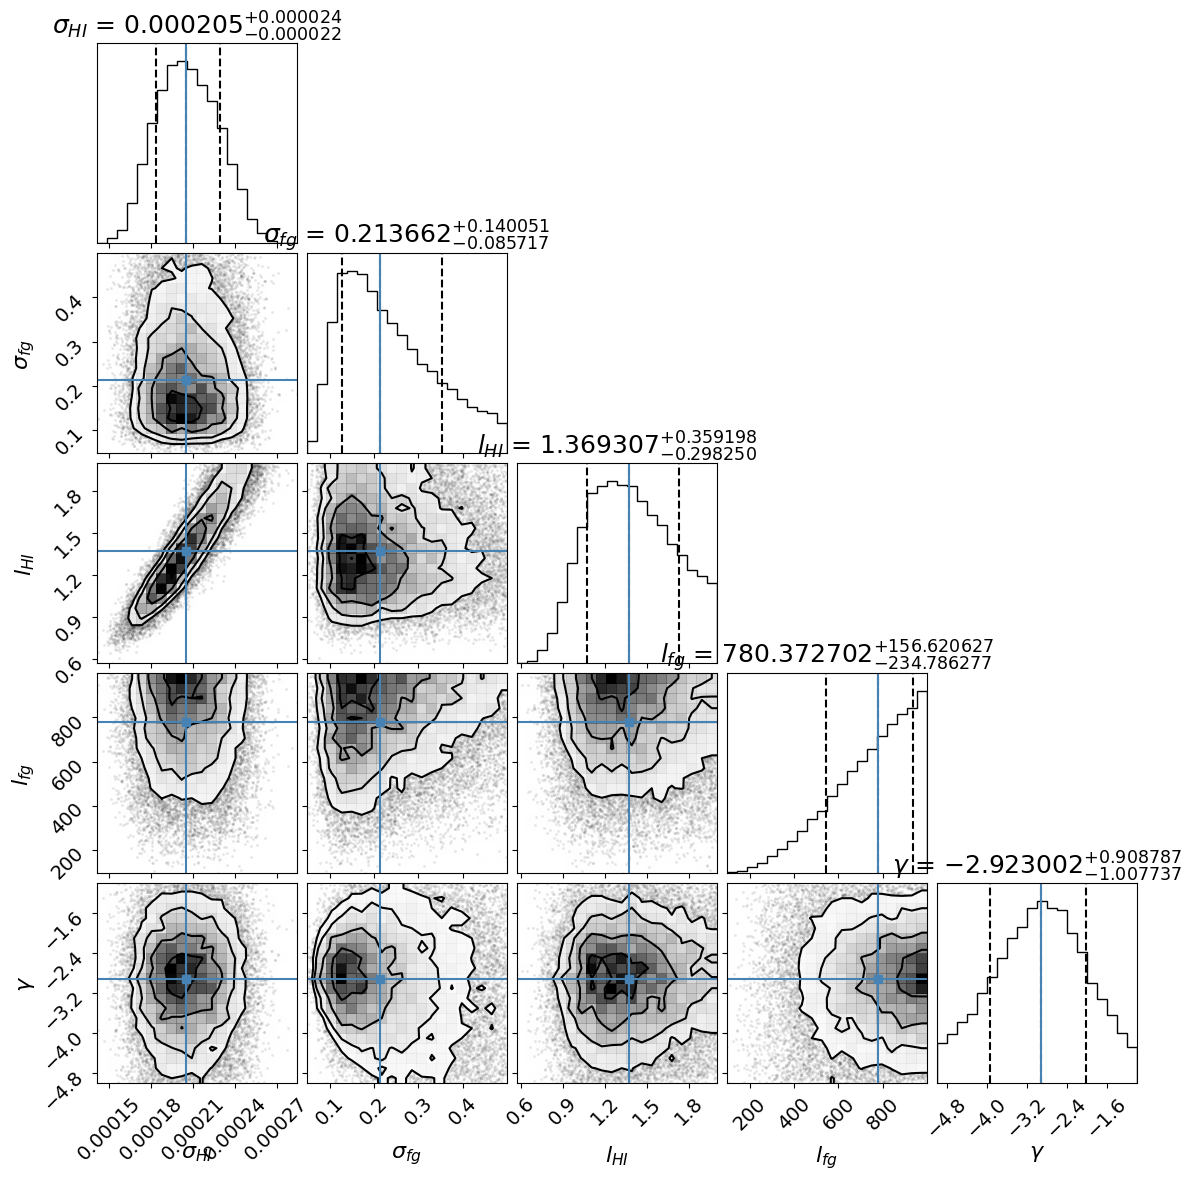

In [152]:
# corner plot
fig = corner.corner(samples, labels=param_titles, truths=medians,
                    quantiles=[0.16, 0.5, 0.84], show_titles=True,
                    title_fmt=".6f")
save_project_plot(plt.gcf(), week_number = 8, filename = "mcmc_corner_plot_with_sp_indx_fg_no_noise.pdf")
plt.show()


Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week8/final_corner_plot_values.pdf


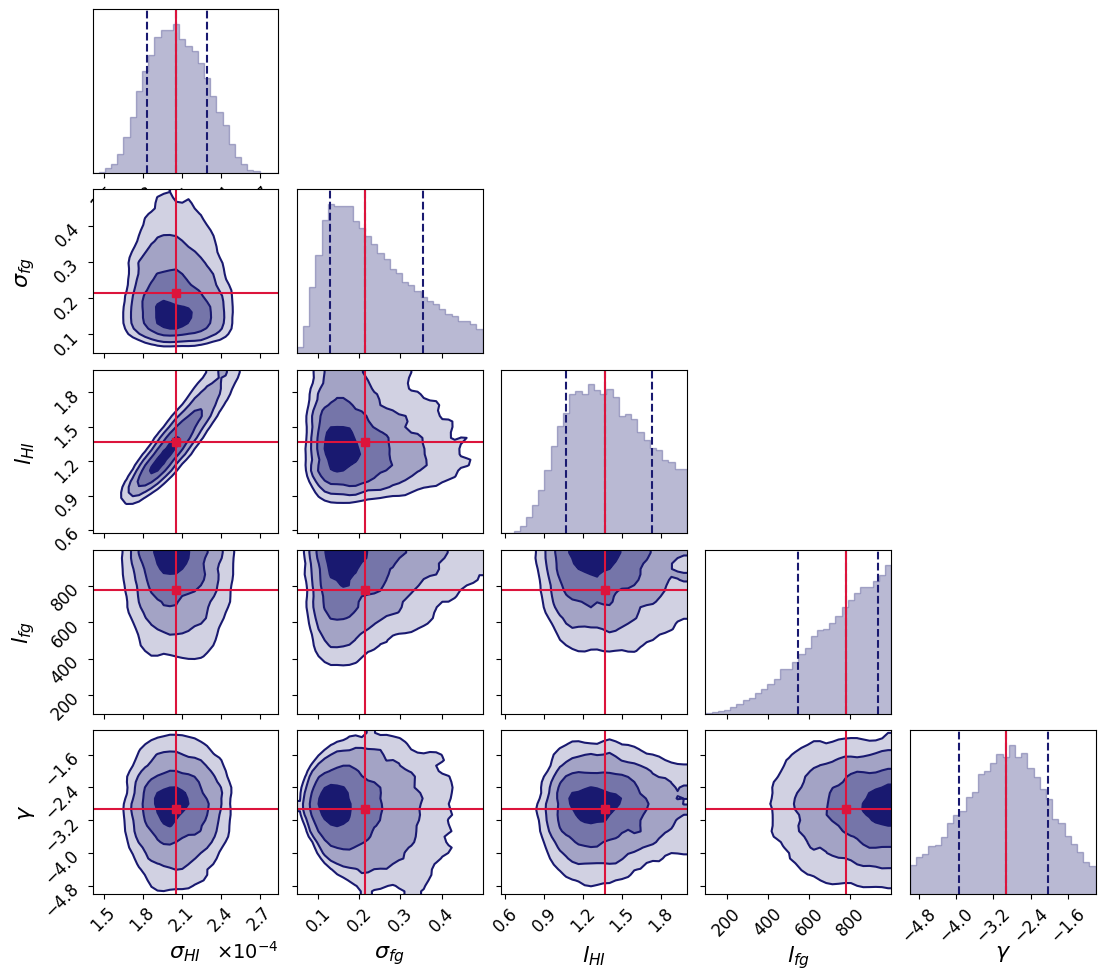

In [153]:
# We use 'serif' for a journal feel and increase the label sizes
#plt.rcParams['font.family'] = 'serif'
fs = 14

# 2. Generate the plot with enhanced styling
fig = corner.corner(
    samples, 
    labels=param_titles, 
    truths=medians,
    quantiles=[0.16, 0.5, 0.84], 
    show_titles=False,           # Change this for values
    title_fmt=".5f",
    title_kwargs={"fontsize": fs},
    label_kwargs={"fontsize": fs + 2, "labelpad": 30},
    
    # Visual Polish
    color="midnightblue",  
    truth_color="crimson", 
    fill_contours=True,        # Fills the 2D density plots
    plot_datapoints=False,     # Removes the "dots" in the clouds (cleaner)
    smooth=0.9,                # Smooths out jagged MCMC noise
    
    # Formatting
    bins=30,                   # More bins for smoother histograms
    hist_kwargs={'alpha': 0.3, 'fill': True} # Fill the 1D histograms
)

for ax in fig.get_axes():
    ax.tick_params(axis='x', rotation=45, labelsize=fs-2)
    ax.tick_params(axis='y', labelsize=fs-2)

# 1. Target the first axis (Top-Left Histogram)
ax0 = fig.axes[0] 
ax0.xaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
ax0.ticklabel_format(style='sci', scilimits=(0,0), axis='x')
ax0.xaxis.get_offset_text().set_fontsize(fs-2)

# 2. Target the bottom-left axis (the X-axis of the last row, first column)
# In a 5x5 corner plot, the bottom-left axis is index 10 (or fig.axes[10])
# A safer way is to loop and check the label
for ax in fig.get_axes():
    if ax.get_xlabel() == param_titles[0]: # Check if the label is sigma_HI
        ax.xaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
        ax.ticklabel_format(style='sci', scilimits=(0,0), axis='x')
        #ax.xaxis.get_offset_text().set_fontsize(fs-2)

# 3. Fine-tune the spacing so labels don't overlap
fig.subplots_adjust(left=0.1, bottom=0.2, right=0.95, top=0.95, wspace=0.1, hspace=0.1)

save_project_plot(fig, week_number=8, filename="final_corner_plot_values.pdf")
plt.show()

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week8/kernel_comparison_mcmc_with_sp_indx_no_noise.pdf


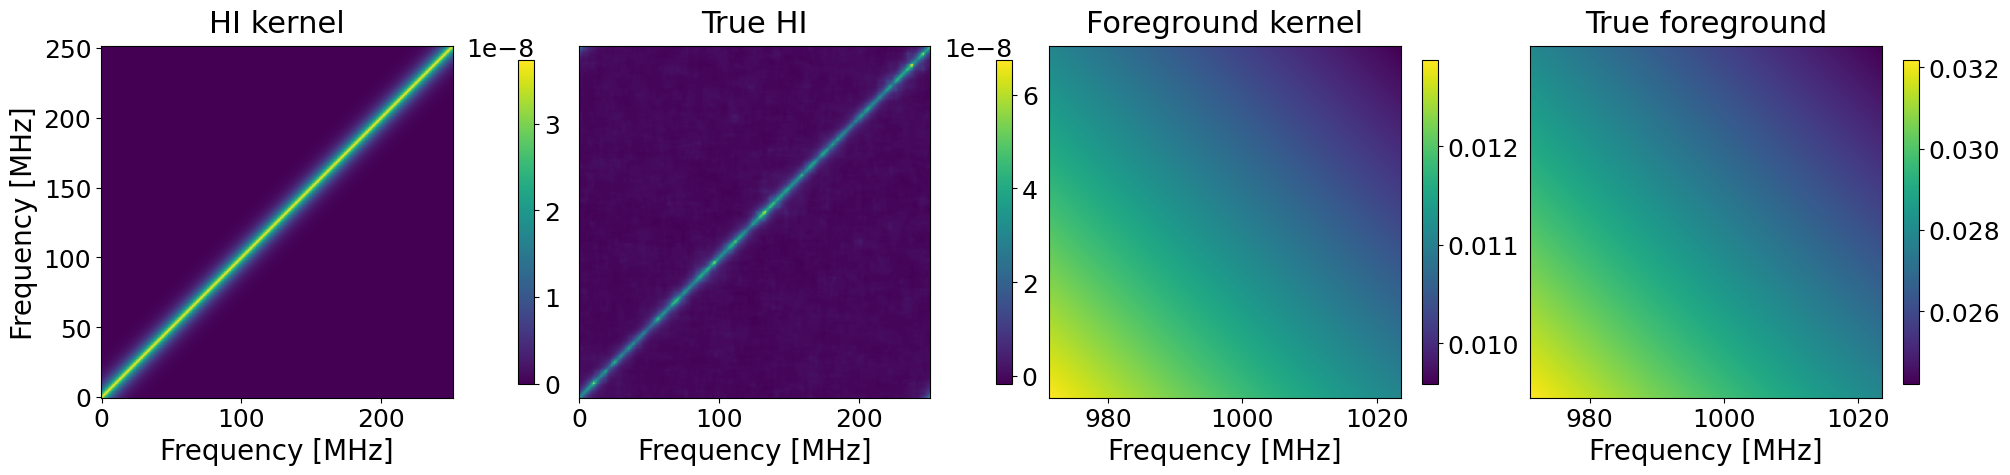

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week8/gpr_1d_power_mcmc_with_sp_indx_no_noise.pdf


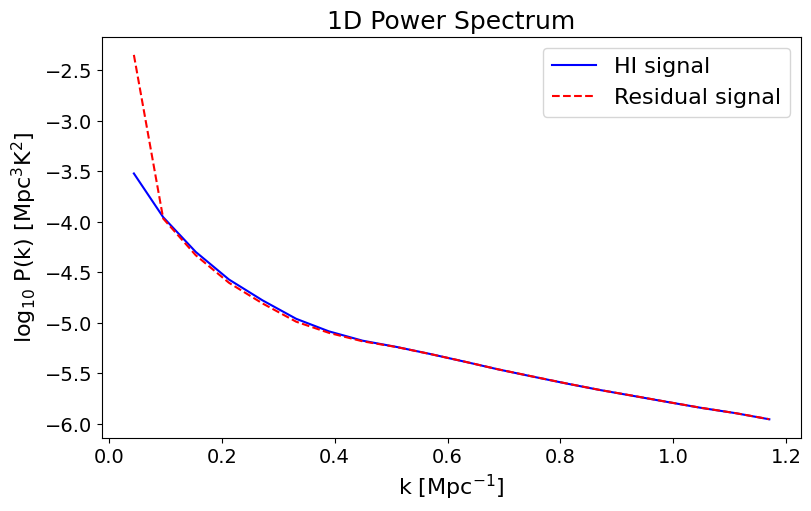

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week8/gpr_cylindrical_mcmc_with_sp_indx_no_noise.pdf


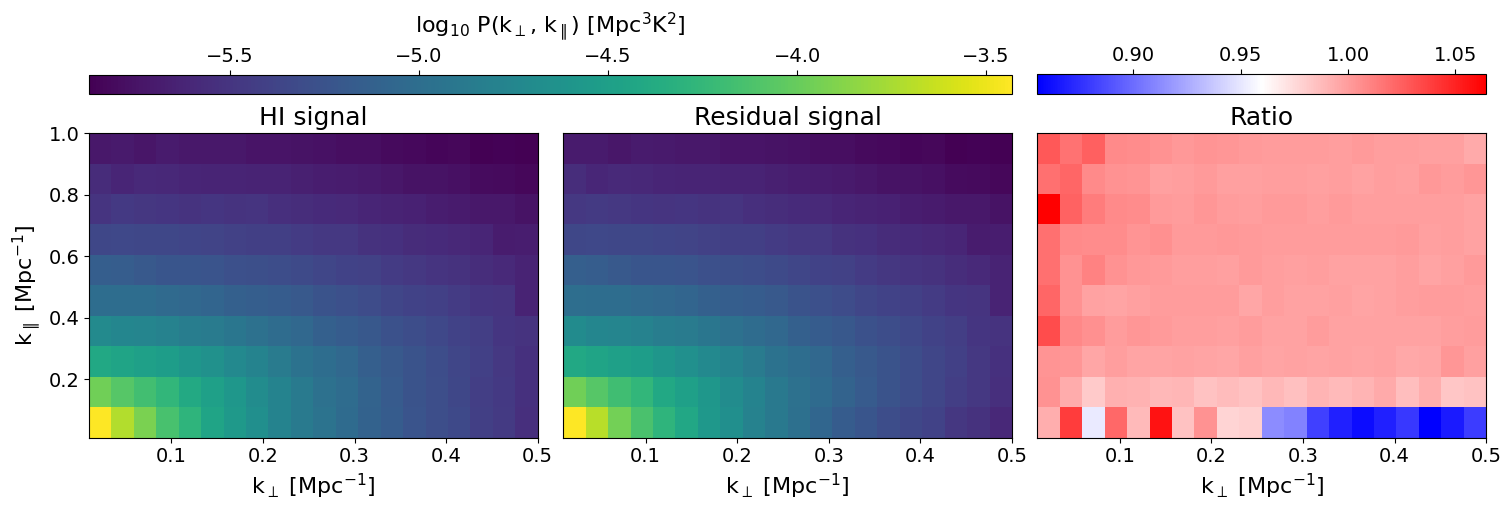

In [167]:
plot_kernel_comparison(best_params, sp_indx_fg=True, noise = False,
                       method='mcmc_with_sp_indx_no_noise', save_plot=True, week_number=8)
plot_gpr_power_spectra(best_params, sp_indx_fg=True, noise = False,
                       method='mcmc_with_sp_indx_no_noise', save_plot=True, week_number=8)

## 9. GPR Power Spectrum with MCMC Uncertainty

Propagate MCMC parameter uncertainty through the foreground removal to produce
error bars on the cleaned power spectrum.

For each of N parameter samples drawn from the posterior, we:
1. Build kernels from those parameters
2. Apply the GPR Wiener filter to clean the map
3. Compute the 1D power spectrum

Error bars show the 16th–84th percentile (≈1σ credible interval) across all realisations.

In [97]:
# Sample from the posterior
n_samples = 1000
idx = np.random.choice(len(samples), n_samples, replace=False)
subset = samples[idx]

power_1d_realisations = []

for i, params in enumerate(subset):
    if i % 10 == 0:
        print(f"  {i}/{n_samples}")
    
    # Build kernels from this sample
    k_hi  = exponential_kernel(mock.nu/1e6, mock.nu/1e6, params[0], params[2])
    k_fg  = rbf_kernel_no_sp_indx(mock.nu/1e6, mock.nu/1e6, params[1], params[3])
    k_tot_fitted = k_hi + k_fg

    # Clean the map
    fg_remov = np.einsum(
        'ij, abj->abi',
        k_fg @ np.linalg.inv(k_tot_fitted),
        tot_map
    )
    res_map = tot_map - fg_remov

    # Noise residual
    #noise_residual = np.einsum(
    #    'ij, abj->abi',
    #    np.eye(mock.nu.size) - k_fg @ np.linalg.inv(k_tot_fitted),
    #    noise_map
    #)

    # Power spectrum
    mock.data = res_map
    mock.grid_data_to_field()
    power_1d_res, k_1d, _ = mock.get_1d_power(mock.auto_power_3d_1)

    #mock.data = noise_residual
    #mock.grid_data_to_field()
    #power_1d_noise, _, _ = mock.get_1d_power(mock.auto_power_3d_1)

    #power_1d_realisations.append(power_1d_res - power_1d_noise)
    power_1d_realisations.append(power_1d_res)

power_1d_realisations = np.array(power_1d_realisations)  # (n_samples, n_k)

# Percentiles across realisations
p16 = np.percentile(power_1d_realisations, 16, axis=0) # lower 1 sigma bound
p50 = np.percentile(power_1d_realisations, 50, axis=0) # median
p84 = np.percentile(power_1d_realisations, 84, axis=0) # upper 1 sigma bound
print("Done!")

  0/1000
  10/1000
  20/1000
  30/1000
  40/1000
  50/1000
  60/1000
  70/1000
  80/1000
  90/1000
  100/1000
  110/1000
  120/1000
  130/1000
  140/1000
  150/1000
  160/1000
  170/1000
  180/1000
  190/1000
  200/1000
  210/1000
  220/1000
  230/1000
  240/1000
  250/1000
  260/1000
  270/1000
  280/1000
  290/1000
  300/1000
  310/1000
  320/1000
  330/1000
  340/1000
  350/1000
  360/1000
  370/1000
  380/1000
  390/1000
  400/1000
  410/1000
  420/1000
  430/1000
  440/1000
  450/1000
  460/1000
  470/1000
  480/1000
  490/1000
  500/1000
  510/1000
  520/1000
  530/1000
  540/1000
  550/1000
  560/1000
  570/1000
  580/1000
  590/1000
  600/1000
  610/1000
  620/1000
  630/1000
  640/1000
  650/1000
  660/1000
  670/1000
  680/1000
  690/1000
  700/1000
  710/1000
  720/1000
  730/1000
  740/1000
  750/1000
  760/1000
  770/1000
  780/1000
  790/1000
  800/1000
  810/1000
  820/1000
  830/1000
  840/1000
  850/1000
  860/1000
  870/1000
  880/1000
  890/1000
  900/1000
  910/1000

In [98]:
# Compute HI power spectrum
mock.kparabins = np.linspace(0.01, 1, 11)
mock.kperpbins = np.linspace(0.01, 0.5, 21)
mock.k1dbins   = np.linspace(0, 1.2, 21)

mock.data = hi_map
mock.grid_data_to_field()
power_cy_hi, _ = mock.get_cy_power(mock.auto_power_3d_1)
power_1d_hi, k_1d, _ = mock.get_1d_power(mock.auto_power_3d_1)

[0.92787024 0.56713115 0.35680754 0.23903846 0.11863323 0.02535401
 0.00389973 0.00355655 0.00189118 0.00241609 0.00166679 0.00251633
 0.00165551 0.00238313 0.00146053 0.00228037 0.00165144 0.00234599
 0.00156853 0.0024685 ]
[0.62352697 0.57021792 0.49169088 0.41355809 0.27671573 0.08664123
 0.01190125 0.01099432 0.00518842 0.00613628 0.00421056 0.00565484
 0.00374828 0.0054521  0.00354101 0.00533151 0.00388098 0.00548574
 0.00385269 0.00602851]
Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week9/final_power_spectrum_1.pdf


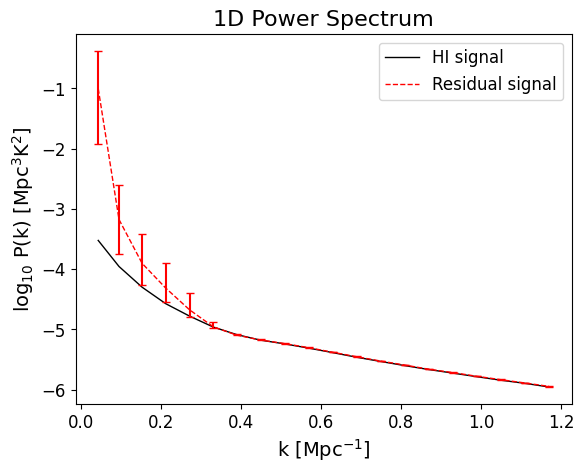

In [99]:
fs = 14

# Plot with error bars
log_p50 = np.log10(p50)
err_lo  = log_p50 - np.log10(p16)
err_hi  = np.log10(p84) - log_p50

print(err_lo)
print(err_hi)

plt.plot(k_1d, np.log10(power_1d_hi), label='HI signal', color='black', linewidth=1)
plt.plot(k_1d, log_p50, label='Residual signal', color='red', linewidth=1, ls='--')
plt.legend(fontsize = fs-2)
plt.errorbar(k_1d, log_p50, yerr=[err_lo, err_hi], fmt='None', markersize = 3,  
             label='Residual signal', color='red', capsize=3)
plt.xlabel('k [Mpc$^{-1}$]', fontsize = fs)
plt.ylabel(r'log$_{10}$ P(k) [Mpc$^{3}$K$^2$]', fontsize = fs)
plt.title('1D Power Spectrum', fontsize = fs+2)
plt.tick_params(labelsize=fs-2)
save_project_plot(plt.gcf(), week_number=9, filename='final_power_spectrum_1.pdf')
plt.show()